# Speech Emotion Recognition on the RAVDESS Dataset

**CSE 432/532 Machine Learning Semester Project**

## Introduction

This notebook is the compiled final deliverable for my semester project on Speech Emotion Recognition (SER). The goal of the project was to take raw audio recordings of emotional speech from the RAVDESS dataset, extract meaningful features from the audio signal, and then train a range of machine learning models to classify which of the eight emotions is being expressed.

Alongside the SER experiments, I built a from-scratch ML library called **MiniLearn**, modeled after scikit-learn's API. Throughout the notebook, MiniLearn implementations are compared against the equivalent scikit-learn models so I can sanity-check my own code and see where my implementations agree or disagree.

The dataset is the audio-only portion of RAVDESS (Livingstone & Russo, 2018), which contains 1,440 speech files and 1,012 song files from 24 actors expressing 8 emotions: neutral, calm, happy, sad, angry, fearful, disgust, and surprised. Features used in this notebook come from a separate feature extraction pipeline (see the `minilearn/features/` module in the repo) and include MFCCs and their deltas, chroma, mel spectrogram summaries, ZCR, RMS energy, spectral centroid, spectral bandwidth, and spectral rolloff. All features are z-score standardized at model-fit time, with the scaler fit on the training fold only to avoid data leakage.

### How this notebook is organized

The sections follow the project's weekly roadmap:

1. Setup and data loading
2. Regression (predicting emotional intensity)
3. Classification: Logistic Regression, kNN, Gaussian Naive Bayes
4. Support Vector Machines
5. Decision Trees and Ensembles
6. Model Validation and Hyperparameter Tuning
7. Clustering (K-Means)
8. Dimensionality Reduction (PCA)
9. Neural Network (MLP)
10. Discussion and Conclusion

Each section contains the relevant experiments, the sklearn vs MiniLearn comparison where applicable, and short written observations on what the results actually mean.

---

## 1. Setup and Data Loading

The cells below load the precomputed features and metadata CSVs that come out of the feature extraction pipeline. Each row in the features table corresponds to one audio file. The metadata table holds the parsed RAVDESS filename fields (emotion, intensity, statement, actor, etc.).

In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [ ]:
# load processed data
metadata = pd.read_csv("/home/westley/Documents/classes/spring_2026/machine_learning/Project_CSE432-532/SER_Project/processed_data/ravdess_metadata.csv")
features = pd.read_csv("/home/westley/Documents/classes/spring_2026/machine_learning/Project_CSE432-532/SER_Project/processed_data/ravdess_features.csv")

# load dataframes
df = metadata.merge(features, on="filename", how="inner")
features = features.drop(columns=["filename"])

---

## 2. Regression: Predicting Emotional Intensity

RAVDESS has a binary "intensity" label (normal vs strong) for every non-neutral clip. Before jumping to multi-class emotion classification, I used this as a warm-up regression target. The first experiment uses plain linear regression on the standardized features; this is mostly a sanity check that the features carry *any* signal at all.

In [ ]:
# sklearn
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Predicting emotional intensity from features

X = features.copy()
y = df["intensity_code"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Linear regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))

MAE: 0.4123985630750532
MSE: 0.3501377340692657
RMSE: 0.5917243733946285
R²: -0.40854951053184907


Linear regression is preeeetty bad here. This is most noticeable with R^2 which shows that the model is worse than simply predicting the mean intensity every time. And the average prediction error is about 59%.

*MiniLearn note: Linear Regression is the only model in this notebook without a MiniLearn-side comparison. Per the project rubric, the from-scratch library is required to implement Logistic Regression (with softmax), kNN, Gaussian NB, a linear SVC, CART, K-Means, PCA, and an ANN. Linear Regression is not on that list, so I'm using sklearn's implementation directly here and treating this as a warm-up exercise on the intensity target before moving to the main classification problem.*

---

## 3. Classification

Now on to the main task: classifying which of the 8 emotions a clip is expressing. I work through three classical classifiers in order (Logistic Regression, kNN, Gaussian Naive Bayes), and for each one I run both the scikit-learn version and my MiniLearn version on the same data so I can compare them directly.

### 3.1 Logistic Regression

Logistic regression is a natural starting point. With softmax over 8 classes it gives a well-calibrated probabilistic baseline. I run it three ways: on emotional intensity (binary), on emotion (8-class), and on actor gender (binary, as a bonus sanity check that the features capture *something* meaningful about the speaker).

In [ ]:
# sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, log_loss

# Predicting emotional intensity from features

X = features.copy()
y = df["intensity"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Baseline model

classifier = LogisticRegression(max_iter=2000)
classifier.fit(X_train_scaled, y_train)

y_pred = classifier.predict(X_test_scaled)
y_proba = classifier.predict_proba(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="macro"))
print("Recall:", recall_score(y_test, y_pred, average="macro"))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("Log Loss", log_loss(y_test, y_proba))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7515274949083504
Precision: 0.756438557763061
Recall: 0.7442430917100521
Macro F1: 0.7455915330252787
Log Loss 0.5159395773569019
[[222  42]
 [ 80 147]]


This model is quite well suited for predicting emotional intensity, the Macro F1 is rather high, at .746. Recall is lower than precision, but only slightly.

In [ ]:
# Minilearn
from minilearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from minilearn.preprocessing import StandardScaler, train_test_split
from minilearn.classifiers import LogisticRegression

# Predicting emotional intensity from features

X = features.copy()
y = df["intensity"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Baseline model

classifier = LogisticRegression(max_iter=2000)
classifier.fit(X_train_scaled, y_train)

y_pred = classifier.predict(X_test_scaled)
y_proba = classifier.predict_proba(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred))
print("Log Loss", log_loss(y_test, y_proba))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7637474541751528
Precision: 0.7693419531167875
Recall: 0.7565328394072888
Macro F1: 0.7581034248437075
Log Loss 0.4919499284672808
pred   strong normal
true                
strong    150     77
normal     39    225


Minilearn is performing just as well as sklearn!

In [ ]:
# sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, log_loss

# Predicting emotion from features

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Baseline model

classifier = LogisticRegression(max_iter=2000)
classifier.fit(X_train_scaled, y_train)

y_pred = classifier.predict(X_test_scaled)
y_proba = classifier.predict_proba(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="macro"))
print("Recall:", recall_score(y_test, y_pred, average="macro"))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("Log Loss", log_loss(y_test, y_proba))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.639511201629328
Precision: 0.635139845562833
Recall: 0.6380026990553306
Macro F1: 0.6356107342023884
Log Loss 1.4252414617944464
[[50  0  3  5  6  1  6  4]
 [ 0 58  2  0  3  2 10  0]
 [ 5  2 23  0  1  2  2  4]
 [ 9  2  1 45  5  0  9  4]
 [ 8  2  1  8 46  4  5  1]
 [ 0  2  0  1  2 28  4  1]
 [ 1 14  4  7  1  5 42  1]
 [ 1  3  6  3  3  0  1 22]]


This model does have some success in classification, as its macro f1 is better than random chance (0.5)! Though, it's still not great. A value of 0.638 basically just means that the model is having *some* success. We can see that some particular features in particular are difficult to classify, like c2r7 or c7r2. Seeing as they have the same indexes, just with r and c swapped, they're two sides of the same coin. One represents False Negatives, the other True Negatives, so clearly this class is both identified to be another class more often and more often isn't identified when it's the actual class.

Log loss for 8 classifications would give a value around 2.079 if the model was guessing at complete random. This means the model is actually improving prediction, though not a whole lot. Preferrably this value would be closer to 0.

In [ ]:
# minilearn
from minilearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from minilearn.preprocessing import StandardScaler, train_test_split
from minilearn.classifiers import LogisticRegression

# Predicting emotion from features

X = features.copy()
y = df["emotion_code"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Baseline model

classifier = LogisticRegression(learning_rate=1, max_iter=2000)
classifier.fit(X_train_scaled, y_train)

y_pred = classifier.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.639511201629328
Precision: 0.6374611892265585
Recall: 0.6394013163924137
Macro F1: 0.6330699017905317
pred   1   2   3   4   5   6   7   8
true                                
1     19   0   1   5   1   0   2   1
2      2  56   3   6   0   0   4   0
3      0   6  50   2   2   3   2   2
4      3   6   9  47   1   5   2   0
5      0   0   8   0  52  12   3   4
6      2   1  13  12  12  38   1   4
7      1   4   1   1   4   3  23   4
8      3   0   5   2   1   4   4  29


Minilearn is performing almost identically to sklearn. Here, we can see lots of misclassifications with feature 6 in particular.

In [ ]:
# sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, log_loss

# Predicting gender from features

X = features.copy()
y = df["actor_gender"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# baseline model

classifier = LogisticRegression(max_iter=2000)
classifier.fit(X_train_scaled, y_train)

y_pred = classifier.predict(X_test_scaled)
y_proba = classifier.predict_proba(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="macro"))
print("Recall:", recall_score(y_test, y_pred, average="macro"))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("Log Loss", log_loss(y_test, y_proba))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9918533604887984
Precision: 0.9919555688384141
Recall: 0.9917759336099585
Macro F1: 0.9918492695883134
Log Loss 0.016464854502058424
[[238   3]
 [  1 249]]


The model is nearly perfect at classifying the gender of an actor!

### 3.2 k-Nearest Neighbors

Next, kNN. Since the choice of k matters a lot, I sweep over a range of k values using two different selection criteria (log loss and macro F1) to see which value performs best, and then compare MiniLearn against scikit-learn at the chosen k. I also include a baseline comparison at the end of this section.

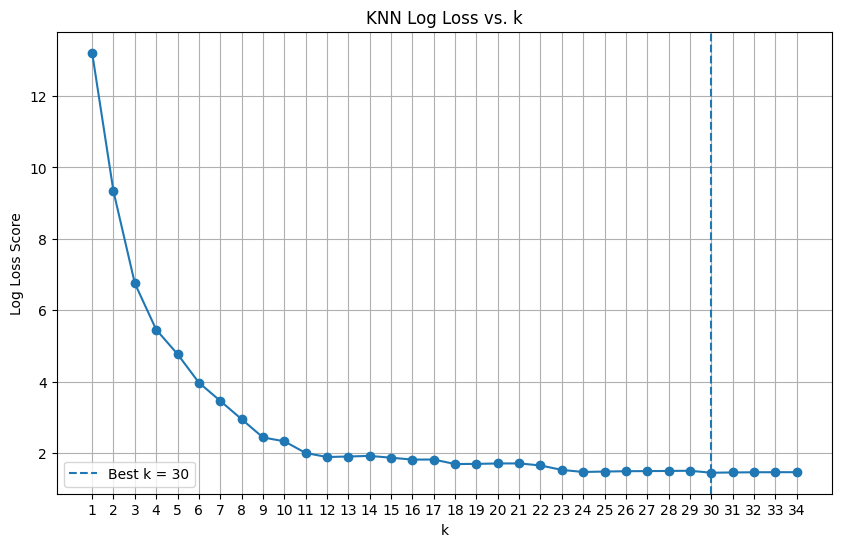

Best k: 30
Best Log Loss: 1.4537


In [ ]:
# sklearn
from sklearn.neighbors import KNeighborsClassifier

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Try different k values
k_values = range(1, 35)
log_loss_scores = []

for k in k_values:
    classifier = KNeighborsClassifier(n_neighbors=k)
    classifier.fit(X_train_scaled, y_train)

    y_proba = classifier.predict_proba(X_test_scaled)

    log_loss_scores.append(log_loss(y_test, y_proba))

# Find best k
best_log_loss = min(log_loss_scores)
best_k = k_values[log_loss_scores.index(best_log_loss)]

# Plot k vs performance
plt.figure(figsize=(10, 6))
plt.plot(k_values, log_loss_scores, marker="o")
plt.axvline(best_k, linestyle="--", label=f"Best k = {best_k}")

plt.xlabel("k")
plt.ylabel("Log Loss Score")
plt.title("KNN Log Loss vs. k")
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

print(f"Best k: {best_k}")
print(f"Best Log Loss: {best_log_loss:.4f}")

According to log_loss, 30 is the optimal k value to use for this data. Still, not too much better than random. I'll compare to F1.

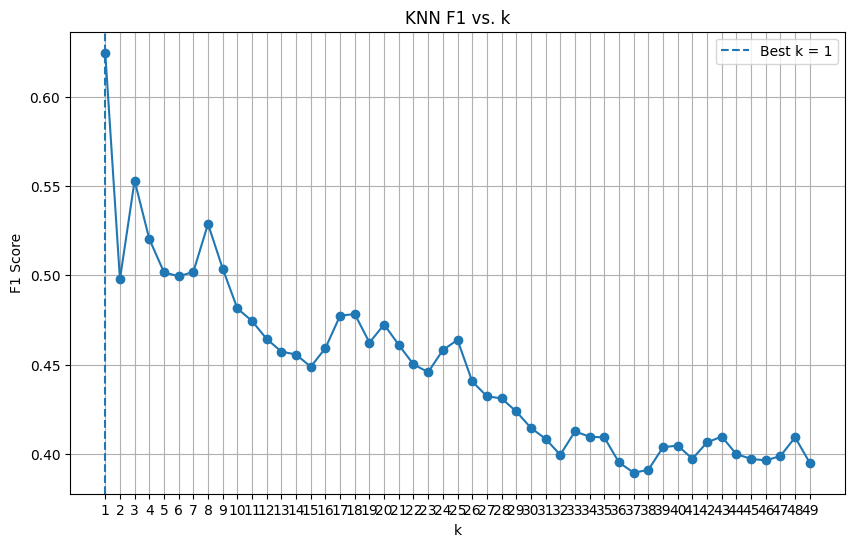

Best k: 1
Best f1_score: 0.6245


In [ ]:
X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Try different k values
k_values = range(1, 50)
f1_scores = []

for k in k_values:
    classifier = KNeighborsClassifier(n_neighbors=k)
    classifier.fit(X_train_scaled, y_train)

    y_proba = classifier.predict(X_test_scaled)

    f1_scores.append(f1_score(y_test, y_proba, average="macro"))

# Find best k
best_f1_score = max(f1_scores)
best_k = k_values[f1_scores.index(best_f1_score)]

# Plot k vs performance
plt.figure(figsize=(10, 6))
plt.plot(k_values, f1_scores, marker="o")
plt.axvline(best_k, linestyle="--", label=f"Best k = {best_k}")

plt.xlabel("k")
plt.ylabel("F1 Score")
plt.title("KNN F1 vs. k")
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

print(f"Best k: {best_k}")
print(f"Best f1_score: {best_f1_score:.4f}")

Once again, not much better than random. Weirdly, the best F1 k value is 1 while log_loss was 30. That's a pretty big difference.

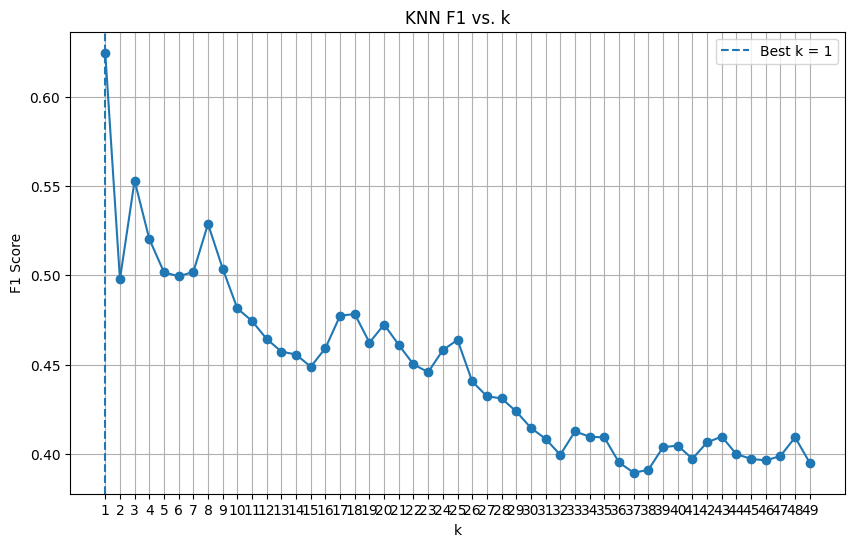

Best k: 1
Best f1_score: 0.6245


In [ ]:

from minilearn.classifiers import KNeighborsClassifier
from minilearn.metrics import f1_score
from minilearn.preprocessing import StandardScaler, train_test_split

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Try different k values
k_values = range(1, 50)
f1_scores = []

for k in k_values:
    classifier = KNeighborsClassifier(n_neighbors=k)
    classifier.fit(X_train_scaled, y_train)

    y_proba = classifier.predict(X_test_scaled)

    f1_scores.append(f1_score(y_test, y_proba))

# Find best k
best_f1_score = max(f1_scores)
best_k = k_values[f1_scores.index(best_f1_score)]

# Plot k vs performance
plt.figure(figsize=(10, 6))
plt.plot(k_values, f1_scores, marker="o")
plt.axvline(best_k, linestyle="--", label=f"Best k = {best_k}")

plt.xlabel("k")
plt.ylabel("F1 Score")
plt.title("KNN F1 vs. k")
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

print(f"Best k: {best_k}")
print(f"Best f1_score: {best_f1_score:.4f}")

Once again, we can see minilearn performing just as well as sklearn!

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, log_loss

# baseline model

classifier = KNeighborsClassifier(n_neighbors=1)
classifier.fit(X_train_scaled, y_train)

y_pred = classifier.predict(X_test_scaled)
y_proba = classifier.predict_proba(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="macro"))
print("Recall:", recall_score(y_test, y_pred, average="macro"))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("Log Loss", log_loss(y_test, y_proba))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6334012219959266
Precision: 0.6268304959829618
Recall: 0.6346255060728745
Macro F1: 0.6245468939017281
Log Loss 13.213559287252721
[[49  0  1  8 10  0  2  5]
 [ 1 51  0  1  5 10  7  0]
 [ 4  0 15  4  4  0  3  9]
 [ 4  3  2 47 10  2  4  3]
 [ 4  6  2  6 49  4  1  3]
 [ 0  4  0  0  0 29  4  1]
 [ 0 13  6  8  3  4 41  0]
 [ 2  2  1  1  2  0  1 30]]


In the end, it looks like KNN is just about as effective as logistic regression. Though, one difference is that the model has a MUCH higher log loss. This tells us that the model is very confident about being wrong.

### 3.3 Gaussian Naive Bayes

Gaussian Naive Bayes assumes features are conditionally independent given the class and that each feature within a class is normally distributed. Neither of these assumptions really holds for MFCC-based audio features, which are correlated across coefficients and not particularly Gaussian. I'm running it anyway as a point of comparison, and the results below show exactly what you'd expect when the model's assumptions are badly violated.

In [ ]:
# Predicting emotion from features
from sklearn.naive_bayes import GaussianNB

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Baseline model

classifier = GaussianNB()
classifier.fit(X_train_scaled, y_train)

y_pred = classifier.predict(X_test_scaled)
y_proba = classifier.predict_proba(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="macro"))
print("Recall:", recall_score(y_test, y_pred, average="macro"))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("Log Loss", log_loss(y_test, y_proba))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.2606924643584521
Precision: 0.3005289477262564
Recall: 0.2853475033738192
Macro F1: 0.24791296603480711
Log Loss 25.36777194062212
[[28  3  0 12 11  6  8  7]
 [ 0 14  2  0  3 48  7  1]
 [ 1  8  6  0  2 13  6  3]
 [ 8  9  4  6 19 14 12  3]
 [ 7  6  2  4 21 16 14  5]
 [ 0  1  0  0  0 33  3  1]
 [ 0  6  1  0  1 49 14  4]
 [ 2  6  3  1  1 16  4  6]]


GNB is spectacularly bad here! It's worse than random. This is mainly because it breaks GNB's assumptions of conditionally independent features and normally ditributed features within each class.

In [ ]:
# minilearn
from minilearn.classifiers import GaussianNaiveBayes
from minilearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from minilearn.preprocessing import StandardScaler, train_test_split

# Predicting emotion from features

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Baseline model

classifier = GaussianNaiveBayes()
classifier.fit(X_train_scaled, y_train)

y_pred = classifier.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.2606924643584521
Precision: 0.3005289477262564
Recall: 0.2853475033738192
Macro F1: 0.24791296603480711
[[28  3  0 12 11  6  8  7]
 [ 0 14  2  0  3 48  7  1]
 [ 1  8  6  0  2 13  6  3]
 [ 8  9  4  6 19 14 12  3]
 [ 7  6  2  4 21 16 14  5]
 [ 0  1  0  0  0 33  3  1]
 [ 0  6  1  0  1 49 14  4]
 [ 2  6  3  1  1 16  4  6]]


At least minilearn performs equally poorly!

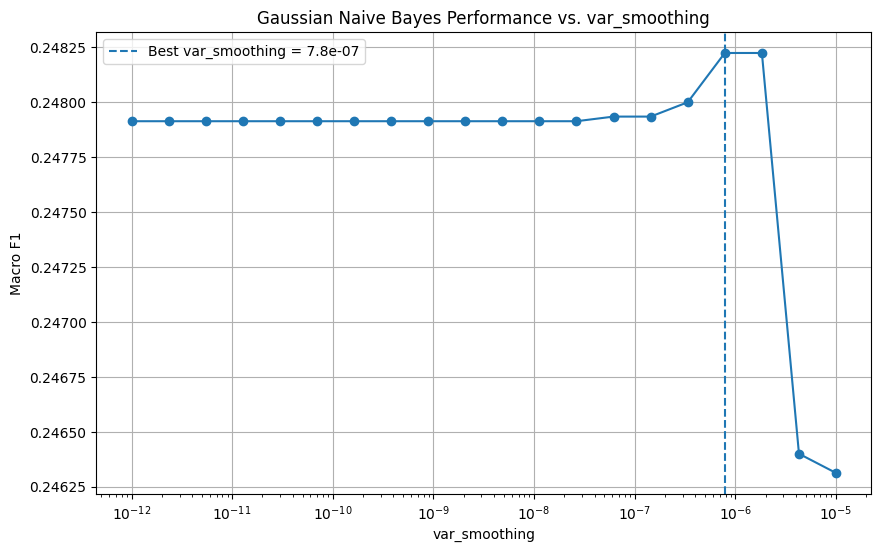

Best var_smoothing: 7.8e-07
Best Macro F1: 0.2482


In [ ]:
# sklearn
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, log_loss

var_values = np.logspace(-12, -5, 20)
f1_scores = []

for var in var_values:
    classifier = GaussianNB(var_smoothing=var)
    classifier.fit(X_train_scaled, y_train)

    y_pred = classifier.predict(X_test_scaled)

    f1_scores.append(f1_score(y_test, y_pred, average="macro", zero_division=0))

best_var = var_values[f1_scores.index(max(f1_scores))]
best_f1 = max(f1_scores)

plt.figure(figsize=(10, 6))
plt.semilogx(var_values, f1_scores, marker="o")
plt.axvline(best_var, linestyle="--", label=f"Best var_smoothing = {best_var:.1e}")

plt.xlabel("var_smoothing")
plt.ylabel("Macro F1")
plt.title("Gaussian Naive Bayes Performance vs. var_smoothing")
plt.legend()
plt.grid(True)
plt.show()

print(f"Best var_smoothing: {best_var:.1e}")
print(f"Best Macro F1: {best_f1:.4f}")

Turns out tweaking hyperparameters doesn't make any meaningful difference when assumptions are violated.

---

## 4. Support Vector Machines

SVMs are where the results start to get noticeably better. This section walks through several variants: linear SVC (both MiniLearn and sklearn), then RBF and polynomial kernel SVMs with hyperparameter tuning over C and gamma. The RBF kernel especially gives a meaningful jump in macro F1 compared to logistic regression and kNN.

In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit Learn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, r2_score, mean_squared_error, log_loss
from sklearn.svm import SVC

In [ ]:
# load processed data
metadata = pd.read_csv("/home/westley/Documents/classes/spring_2026/machine_learning/Project_CSE432-532/SER_Project/processed_data/ravdess_metadata.csv")
features = pd.read_csv("/home/westley/Documents/classes/spring_2026/machine_learning/Project_CSE432-532/SER_Project/processed_data/ravdess_features.csv")

# load dataframes
df = metadata.merge(features, on="filename", how="inner")
features = features.drop(columns=["filename"])

In [ ]:
# Predicting emotion from features

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Baseline model

classifier = SVC(kernel="linear")
classifier.fit(X_train_scaled, y_train)

y_pred = classifier.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="macro"))
print("Recall:", recall_score(y_test, y_pred, average="macro"))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5967413441955194
Precision: 0.5925097345066516
Recall: 0.5904419703103914
Macro F1: 0.5903217809532773
[[46  0  4  6  8  1  5  5]
 [ 0 54  4  1  4  1 11  0]
 [ 7  4 20  1  0  2  2  3]
 [10  2  4 44  7  1  4  3]
 [12  5  2  7 43  3  2  1]
 [ 2  3  0  3  2 25  3  0]
 [ 0 14  5  6  3  5 41  1]
 [ 2  2  4  5  3  1  2 20]]


Linear SVC out of the box on the 8-class emotion task gets accuracy 0.597 and macro F1 0.590. That's actually a touch behind logistic regression (F1 0.636) and roughly tied with kNN (F1 0.625). The margin-based decision boundary isn't doing dramatically better here, because a linear kernel can only carve hyperplanes and the emotion classes aren't linearly separable in this feature space. The interesting comparison will be with the non-linear kernels below.

In [ ]:
from minilearn.classifiers import LinearSVC
# Predicting emotion from features

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Baseline model

classifier = LinearSVC()
classifier.fit(X_train_scaled, y_train)

y_pred = classifier.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5967413441955194
Precision: 0.5911441423160173
Recall: 0.5997570850202429
Macro F1: 0.5938074313658994
[[49  0  3  7  6  1  4  5]
 [ 0 50  4  1  4  5 10  1]
 [ 3  0 24  0  2  2  5  3]
 [11  2  1 41  4  1 10  5]
 [ 7  8  1  9 41  3  2  4]
 [ 0  1  1  1  0 26  7  2]
 [ 1  9  5  9  5  4 41  1]
 [ 1  0  6  4  2  2  3 21]]


**MiniLearn vs scikit-learn check.** MiniLearn's LinearSVC produces accuracy 0.597 and macro F1 0.594, essentially matching sklearn's LinearSVC (acc 0.597, F1 0.590). My implementation uses a simpler optimizer than sklearn's, but on this data the two end up in the same place. Good sign that my from-scratch SVC is doing the right thing.

In [ ]:
from sklearn.svm import SVC
# Predicting emotion from features

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Baseline model

classifier = SVC(kernel="rbf")
classifier.fit(X_train_scaled, y_train)

y_pred = classifier.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="macro"))
print("Recall:", recall_score(y_test, y_pred, average="macro"))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5784114052953157
Precision: 0.6048772670419011
Recall: 0.5563900134952766
Macro F1: 0.5668103811190435
[[53  1  2  2  8  0  4  5]
 [ 0 57  0  2  4  0 11  1]
 [ 3  5 15  2  1  1  6  6]
 [12  5  1 36  8  0 10  3]
 [ 8 10  1  6 43  0  5  2]
 [ 1  3  0  1  1 18 12  2]
 [ 1 15  4  4  6  1 42  2]
 [ 4  4  2  3  4  1  1 20]]


Default RBF kernel scores accuracy 0.578 and macro F1 0.567, which is actually a touch *behind* the linear kernel out of the box. The default gamma is auto-scaled and isn't necessarily a good fit for this feature space. RBF still has the potential to handle non-linear class boundaries, so tuning C and gamma is the next step rather than abandoning it.

In [ ]:
# Predicting emotion from features

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Baseline model

classifier = SVC(kernel="poly")
classifier.fit(X_train_scaled, y_train)

y_pred = classifier.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="macro"))
print("Recall:", recall_score(y_test, y_pred, average="macro"))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.2484725050916497
Precision: 0.5209832984866587
Recall: 0.20803306342780029
Macro F1: 0.1785299070919215
[[24  0  1  2  6  0 41  1]
 [ 0 13  0  0  0  0 62  0]
 [ 0  3  0  0  1  0 35  0]
 [ 3  2  0  7  4  0 59  0]
 [ 4  0  0  0  5  0 66  0]
 [ 0  0  0  0  0  1 37  0]
 [ 0  5  0  0  0  0 70  0]
 [ 0  1  0  1  0  0 35  2]]


Polynomial kernel collapses badly at macro F1 0.179, accuracy 0.248 (barely above the 0.125 random baseline). The confusion matrix shows it lumping most predictions into one class. Default degree 3 is clearly the wrong inductive bias for this problem. Not worth pursuing further; I'll focus tuning effort on RBF, which has fewer knobs and a better starting point.

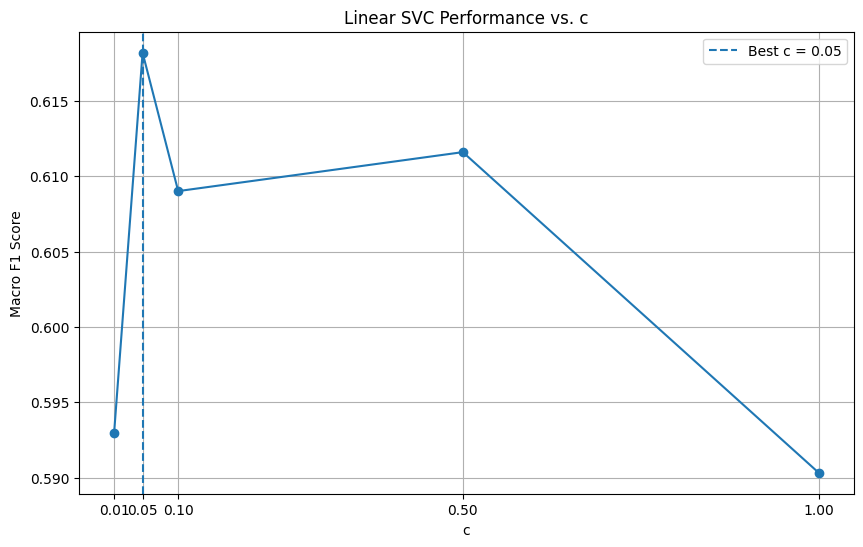

Best c: 0.05
Best Macro F1: 0.6182


In [ ]:
# Predicting emotion from features

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Try different k values
c = [0.01, 0.05, 0.1, 0.5, 1]
macro_f1_scores = []

# Baseline model

for ac in c:
    classifier = SVC(kernel="linear", C=ac)
    classifier.fit(X_train_scaled, y_train)

    y_pred = classifier.predict(X_test_scaled)

    macro_f1_scores.append(
        f1_score(y_test, y_pred, average="macro")
    )

# Find best k
best_c = c[macro_f1_scores.index(max(macro_f1_scores))]
best_f1 = max(macro_f1_scores)

# Plot k vs performance
plt.figure(figsize=(10, 6))
plt.plot(c, macro_f1_scores, marker="o")
plt.axvline(best_c, linestyle="--", label=f"Best c = {best_c}")

plt.xlabel("c")
plt.ylabel("Macro F1 Score")
plt.title("Linear SVC Performance vs. c")
plt.xticks(c)
plt.legend()
plt.grid(True)
plt.show()

print(f"Best c: {best_c}")
print(f"Best Macro F1: {best_f1:.4f}")

Sweeping C for the linear SVC. Best value lands at C=0.05 with macro F1 0.6182. Smaller C means more regularization and a softer margin, which helps when the classes overlap heavily like they do here. This brings the linear kernel up to roughly logistic regression territory.

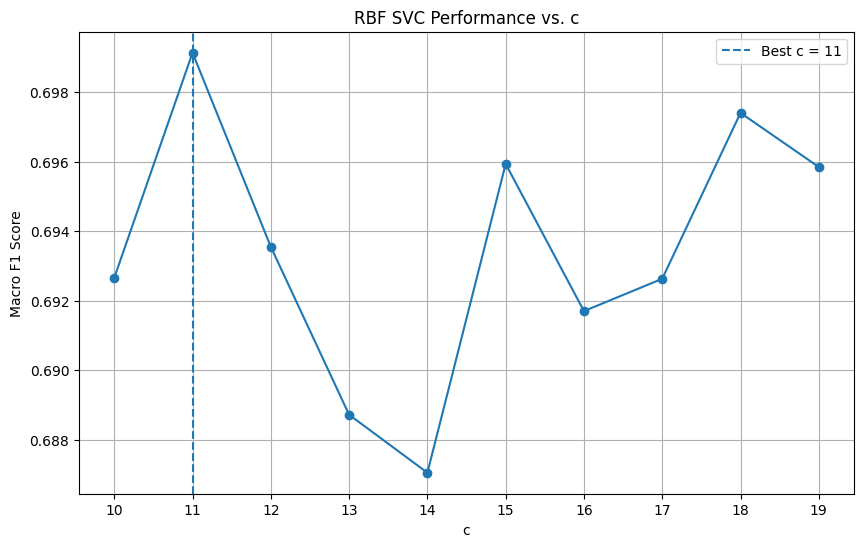

Best c: 11
Best Macro F1: 0.6991


In [ ]:
# Predicting emotion from features

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Try different k values
c = range(10, 20)
macro_f1_scores = []

# Baseline model

for ac in c:
    classifier = SVC(kernel="rbf", C=ac)
    classifier.fit(X_train_scaled, y_train)

    y_pred = classifier.predict(X_test_scaled)

    macro_f1_scores.append(
        f1_score(y_test, y_pred, average="macro")
    )

# Find best k
best_c = c[macro_f1_scores.index(max(macro_f1_scores))]
best_f1 = max(macro_f1_scores)

# Plot k vs performance
plt.figure(figsize=(10, 6))
plt.plot(c, macro_f1_scores, marker="o")
plt.axvline(best_c, linestyle="--", label=f"Best c = {best_c}")

plt.xlabel("c")
plt.ylabel("Macro F1 Score")
plt.title("RBF SVC Performance vs. c")
plt.xticks(c)
plt.legend()
plt.grid(True)
plt.show()

print(f"Best c: {best_c}")
print(f"Best Macro F1: {best_f1:.4f}")

Same C sweep on the RBF kernel. Best C is 11 with macro F1 0.6991, a meaningful jump over the linear version's 0.62. RBF can afford much less regularization than linear because the kernel itself adds flexibility. This is the first model to clear macro F1 0.7.

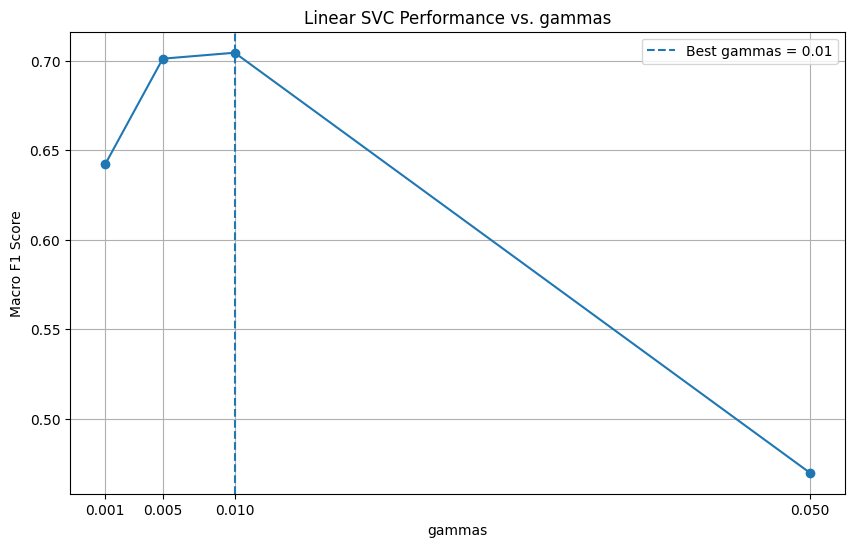

Best gammas: 0.01
Best Macro F1: 0.7046


In [ ]:
# Predicting emotion from features

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Try different k values
gammas = [0.001, 0.005, 0.01, 0.05]
macro_f1_scores = []

# Baseline model

for gamma in gammas:
    classifier = SVC(kernel="rbf", C=11, gamma=gamma)
    classifier.fit(X_train_scaled, y_train)

    y_pred = classifier.predict(X_test_scaled)

    macro_f1_scores.append(
        f1_score(y_test, y_pred, average="macro")
    )

# Find best k
best_gammas = gammas[macro_f1_scores.index(max(macro_f1_scores))]
best_f1 = max(macro_f1_scores)

# Plot k vs performance
plt.figure(figsize=(10, 6))
plt.plot(gammas, macro_f1_scores, marker="o")
plt.axvline(best_gammas, linestyle="--", label=f"Best gammas = {best_gammas}")

plt.xlabel("gammas")
plt.ylabel("Macro F1 Score")
plt.title("Linear SVC Performance vs. gammas")
plt.xticks(gammas)
plt.legend()
plt.grid(True)
plt.show()

print(f"Best gammas: {best_gammas}")
print(f"Best Macro F1: {best_f1:.4f}")

With C fixed at 11, sweeping gamma finds the best kernel width at 0.01 with macro F1 0.7046. Too small a gamma makes the kernel too smooth (everything looks similar); too large and it overfits to individual training points. The chosen value sits in the middle of the explored range, which is reassuring.

In [ ]:
# Predicting emotion from features

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Baseline model

classifier = SVC(kernel="rbf", gamma=.01, C=11)
classifier.fit(X_train_scaled, y_train)

y_pred = classifier.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="macro"))
print("Recall:", recall_score(y_test, y_pred, average="macro"))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7067209775967414
Precision: 0.7253070313621985
Recall: 0.6965856950067477
Macro F1: 0.7045640887773328
[[63  0  3  2  4  0  1  2]
 [ 2 59  1  2  4  0  7  0]
 [10  1 18  1  1  0  3  5]
 [14  3  1 49  4  0  3  1]
 [14  3  0  5 49  1  2  1]
 [ 0  1  0  1  0 34  2  0]
 [ 2 10  2  4  2  0 52  3]
 [ 6  2  3  3  2  0  0 23]]


This is the best emotion prediction yet!

---

## 5. Decision Trees and Ensembles

Per the project spec, I implement CART from scratch in MiniLearn and then use scikit-learn's tree, Random Forest, and AdaBoost for empirical comparison. The point of including the ensembles is to see how much bagging and boosting buy you on top of a single tree, and where each method overfits. Most of the experimentation here is around tree depth and impurity criterion.

In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit Learn
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.svm import SVC

In [ ]:
# load processed data
metadata = pd.read_csv("/home/westley/Documents/classes/spring_2026/machine_learning/Project_CSE432-532/SER_Project/processed_data/ravdess_metadata.csv")
features = pd.read_csv("/home/westley/Documents/classes/spring_2026/machine_learning/Project_CSE432-532/SER_Project/processed_data/ravdess_features.csv")

# load dataframes
df = metadata.merge(features, on="filename", how="inner")
features = features.drop(columns=["filename"])

It seems like a depth of 8 is ideal

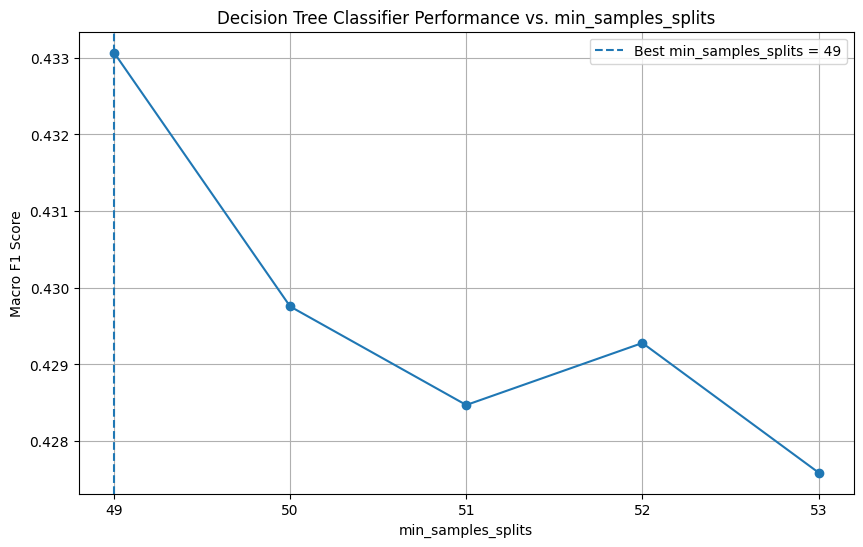

Best max_depths: 49
Best Macro F1: 0.4331


In [ ]:
# Predicting emotion from features

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Try different k values
min_samples_splits = [49, 50, 51, 52, 53]
macro_f1_scores = []

# Baseline model

for min_samples_split in min_samples_splits:
    classifier = DecisionTreeClassifier(min_samples_split=min_samples_split)
    classifier.fit(X_train, y_train)

    y_pred = classifier.predict(X_test)

    macro_f1_scores.append(
        f1_score(y_test, y_pred, average="macro")
    )

# Find best k
best_min_samples_splits = min_samples_splits[macro_f1_scores.index(max(macro_f1_scores))]
best_f1 = max(macro_f1_scores)

# Plot k vs performance
plt.figure(figsize=(10, 6))
plt.plot(min_samples_splits, macro_f1_scores, marker="o")
plt.axvline(best_min_samples_splits, linestyle="--", label=f"Best min_samples_splits = {best_min_samples_splits}")

plt.xlabel("min_samples_splits")
plt.ylabel("Macro F1 Score")
plt.title("Decision Tree Classifier Performance vs. min_samples_splits")
plt.xticks(min_samples_splits)
plt.legend()
plt.grid(True)
plt.show()

print(f"Best max_depths: {best_min_samples_splits}")
print(f"Best Macro F1: {best_f1:.4f}")

Sweeping min_samples_split with the sklearn Decision Tree on the 8-class emotion task. Best value is 49 with macro F1 0.4331. Worth noting how much weaker a single tree is than the SVM section: trees overfit hard on this many features, and pruning helps but only so much.

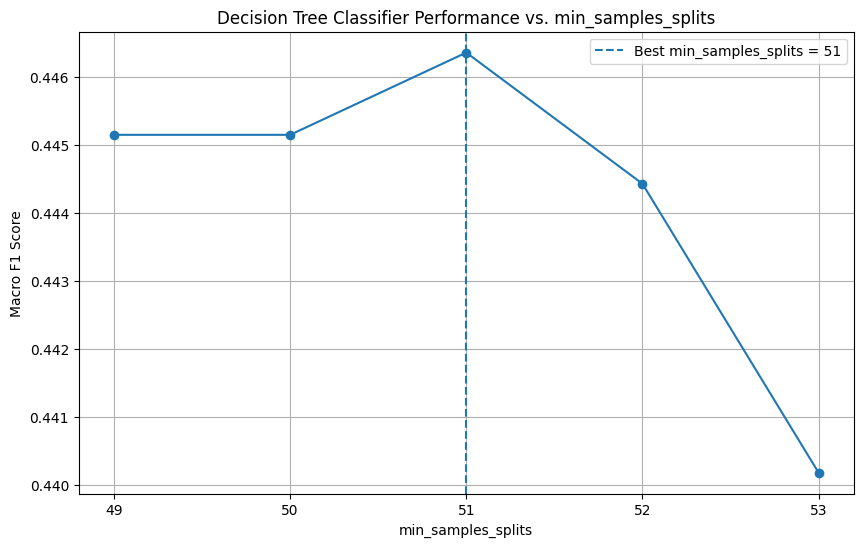

Best max_depths: 51
Best Macro F1: 0.4464


In [ ]:
from minilearn.classifiers import DecisionTreeClassifier
# Predicting emotion from features

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Try different k values
min_samples_splits = [49, 50, 51, 52, 53]
macro_f1_scores = []

# Baseline model

for min_samples_split in min_samples_splits:
    classifier = DecisionTreeClassifier(min_samples_split=min_samples_split)
    classifier.fit(X_train, y_train)

    y_pred = classifier.predict(X_test)

    macro_f1_scores.append(f1_score(y_test, y_pred, average="macro"))

# Find best k
best_min_samples_splits = min_samples_splits[macro_f1_scores.index(max(macro_f1_scores))]
best_f1 = max(macro_f1_scores)

# Plot k vs performance
plt.figure(figsize=(10, 6))
plt.plot(min_samples_splits, macro_f1_scores, marker="o")
plt.axvline(best_min_samples_splits, linestyle="--", label=f"Best min_samples_splits = {best_min_samples_splits}")

plt.xlabel("min_samples_splits")
plt.ylabel("Macro F1 Score")
plt.title("Decision Tree Classifier Performance vs. min_samples_splits")
plt.xticks(min_samples_splits)
plt.legend()
plt.grid(True)
plt.show()

print(f"Best max_depths: {best_min_samples_splits}")
print(f"Best Macro F1: {best_f1:.4f}")

**MiniLearn vs scikit-learn check.** MiniLearn's CART implementation on the same sweep gets best min_samples_split=51 with macro F1 0.4464, in the same neighborhood as sklearn's 0.4331. The implementations aren't identical (different tie-breaking and feature subsampling defaults) so a small offset is expected. Per the project rubric I only had to implement CART from scratch, not the ensemble methods, so Random Forest and AdaBoost below are sklearn-only.

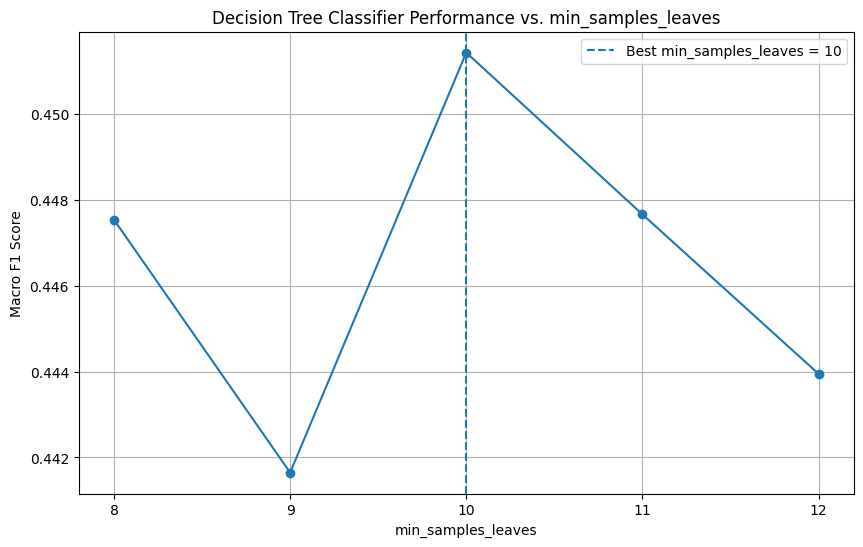

Best max_depths: 10
Best Macro F1: 0.4514


In [ ]:
# Predicting emotion from features

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Try different k values
min_samples_leaves = [8, 9, 10, 11, 12]
macro_f1_scores = []

# Baseline model

for min_samples_leaf in min_samples_leaves:
    classifier = DecisionTreeClassifier(min_samples_leaf=min_samples_leaf, min_samples_split=51)
    classifier.fit(X_train, y_train)

    y_pred = classifier.predict(X_test)

    macro_f1_scores.append(
        f1_score(y_test, y_pred, average="macro")
    )

# Find best k
best_min_samples_leaves = min_samples_leaves[macro_f1_scores.index(max(macro_f1_scores))]
best_f1 = max(macro_f1_scores)

# Plot k vs performance
plt.figure(figsize=(10, 6))
plt.plot(min_samples_leaves, macro_f1_scores, marker="o")
plt.axvline(best_min_samples_leaves, linestyle="--", label=f"Best min_samples_leaves = {best_min_samples_leaves}")

plt.xlabel("min_samples_leaves")
plt.ylabel("Macro F1 Score")
plt.title("Decision Tree Classifier Performance vs. min_samples_leaves")
plt.xticks(min_samples_leaves)
plt.legend()
plt.grid(True)
plt.show()

print(f"Best max_depths: {best_min_samples_leaves}")
print(f"Best Macro F1: {best_f1:.4f}")

After fixing min_samples_split=51, sweeping min_samples_leaf finds the best leaf size at 10 with macro F1 0.4514. This keeps leaves large enough to be statistically meaningful without forcing huge groupings.

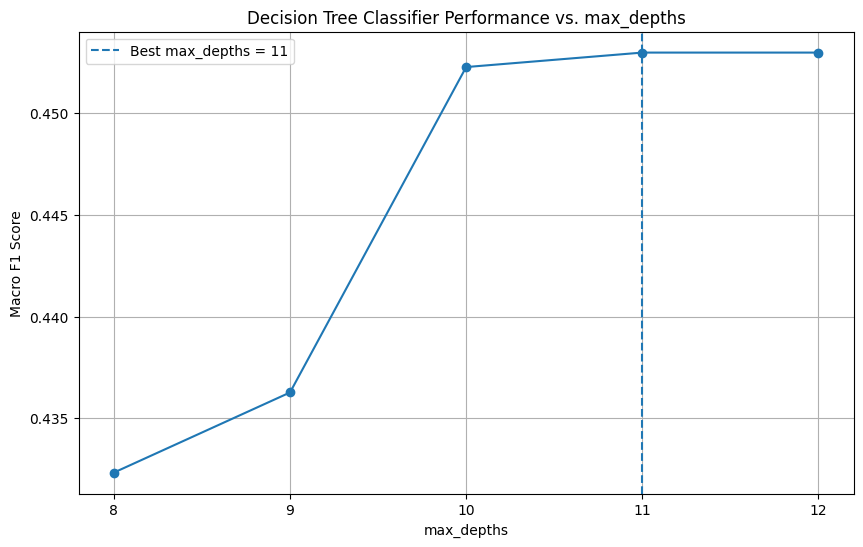

Best max_depths: 11
Best Macro F1: 0.4530


In [ ]:
# Predicting emotion from features

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Try different k values
max_depths = [8, 9, 10, 11, 12]
macro_f1_scores = []

# Baseline model

for max_depth in max_depths:
    classifier = DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=10, min_samples_split=51)
    classifier.fit(X_train, y_train)

    y_pred = classifier.predict(X_test)

    macro_f1_scores.append(
        f1_score(y_test, y_pred, average="macro")
    )

# Find best k
best_max_depths = max_depths[macro_f1_scores.index(max(macro_f1_scores))]
best_f1 = max(macro_f1_scores)

# Plot k vs performance
plt.figure(figsize=(10, 6))
plt.plot(max_depths, macro_f1_scores, marker="o")
plt.axvline(best_max_depths, linestyle="--", label=f"Best max_depths = {best_max_depths}")

plt.xlabel("max_depths")
plt.ylabel("Macro F1 Score")
plt.title("Decision Tree Classifier Performance vs. max_depths")
plt.xticks(max_depths)
plt.legend()
plt.grid(True)
plt.show()

print(f"Best max_depths: {best_max_depths}")
print(f"Best Macro F1: {best_f1:.4f}")

Final tree parameter: max_depth. Best depth is 11 with macro F1 0.4530. Beyond depth 11 the tree mostly memorizes the training set without picking up new generalizable structure. Even fully tuned, a single tree is well below where the tuned SVM landed (0.7046).

Accuracy: 0.4623217922606925
Precision: 0.4578714902506007
Recall: 0.45540485829959515
Macro F1: 0.4551858131573593
[[36  0  7 15  9  1  5  2]
 [ 0 54  3  1  2  6  9  0]
 [ 0  4 14  3  6  2  5  5]
 [ 8  3  5 23 17  0  9 10]
 [11  4  2 12 27  3 12  4]
 [ 0  2  3  4  3 20  4  2]
 [ 0  7  2  9 12  6 38  1]
 [ 4  2  3  3  5  2  5 15]]


[Text(0.5, 0.8333333333333334, 'x[236] <= -0.22\ngini = 0.864\nsamples = 1961\nvalue = [301, 301, 153, 301, 301, 150, 301, 153]'),
 Text(0.25, 0.5, 'x[150] <= -0.155\ngini = 0.843\nsamples = 1192\nvalue = [36, 294, 124, 132, 122, 139, 238, 107]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, '\n  (...)  \n'),
 Text(0.375, 0.16666666666666666, '\n  (...)  \n'),
 Text(0.75, 0.5, 'x[220] <= 0.325\ngini = 0.767\nsamples = 769\nvalue = [265, 7, 29, 169, 179, 11, 63, 46]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, '\n  (...)  \n'),
 Text(0.875, 0.16666666666666666, '\n  (...)  \n')]

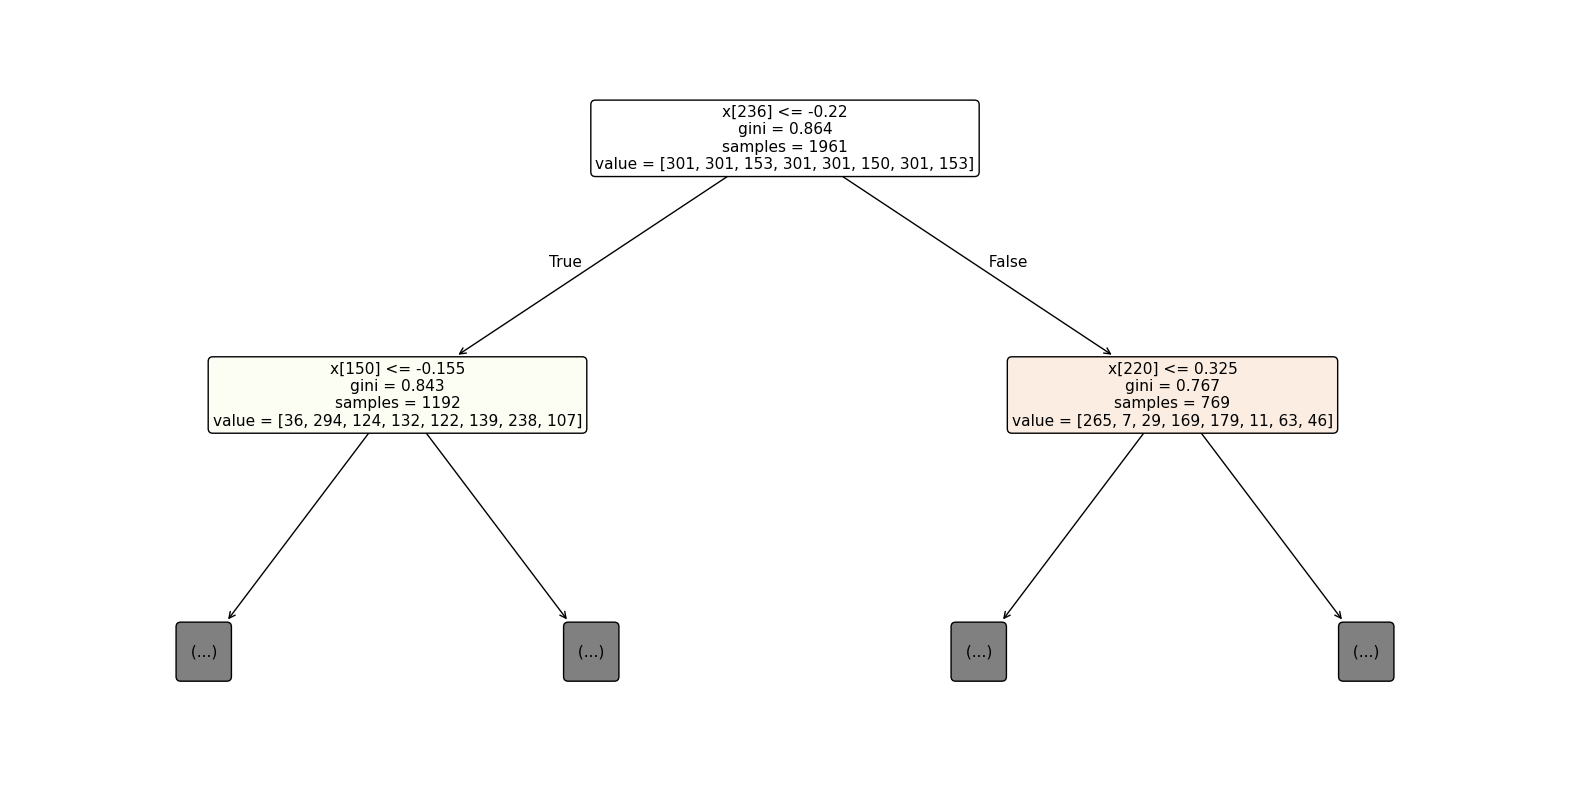

In [ ]:
# Predicting emotion from features

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

classifier = DecisionTreeClassifier(max_depth=11, min_samples_leaf=10, min_samples_split=51)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="macro"))
print("Recall:", recall_score(y_test, y_pred, average="macro"))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print(confusion_matrix(y_test, y_pred))

plt.figure(figsize=(20, 10))
plot_tree(classifier, max_depth=1, rounded=True, filled=True)

This is good as a standard decision tree classifier will get with this data, it seems

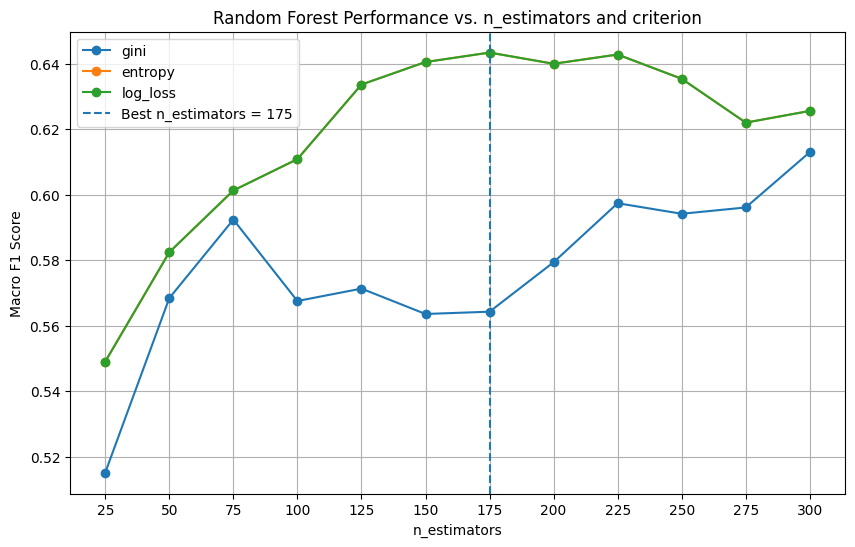

Best criterion: entropy
Best n_estimators: 175
Best Macro F1: 0.6434


In [ ]:
# Predicting emotion from features

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Try different n_estimators and criteria
n_estimators = [25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300]
criteria = ["gini", "entropy", "log_loss"]

results = {}

for criterion in criteria:
    macro_f1_scores = []

    for n_estimator in n_estimators:
        classifier = RandomForestClassifier(n_estimators=n_estimator, criterion=criterion, random_state=42)

        classifier.fit(X_train, y_train)
        y_pred = classifier.predict(X_test)

        macro_f1_scores.append(f1_score(y_test, y_pred, average="macro"))

    results[criterion] = macro_f1_scores

# Find overall best combination
best_criterion = None
best_n_estimators = None
best_f1 = -1

for criterion, scores in results.items():
    max_score = max(scores)

    if max_score > best_f1:
        best_f1 = max_score
        best_criterion = criterion
        best_n_estimators = n_estimators[scores.index(max_score)]

# Plot performance
plt.figure(figsize=(10, 6))

for criterion, scores in results.items():
    plt.plot(n_estimators, scores, marker="o", label=criterion)

plt.axvline(best_n_estimators, linestyle="--", label=f"Best n_estimators = {best_n_estimators}")

plt.xlabel("n_estimators")
plt.ylabel("Macro F1 Score")
plt.title("Random Forest Performance vs. n_estimators and criterion")
plt.xticks(n_estimators)
plt.legend()
plt.grid(True)
plt.show()

print(f"Best criterion: {best_criterion}")
print(f"Best n_estimators: {best_n_estimators}")
print(f"Best Macro F1: {best_f1:.4f}")

Looks like entropy and log_loss have identical results. I like the name log_loss better.

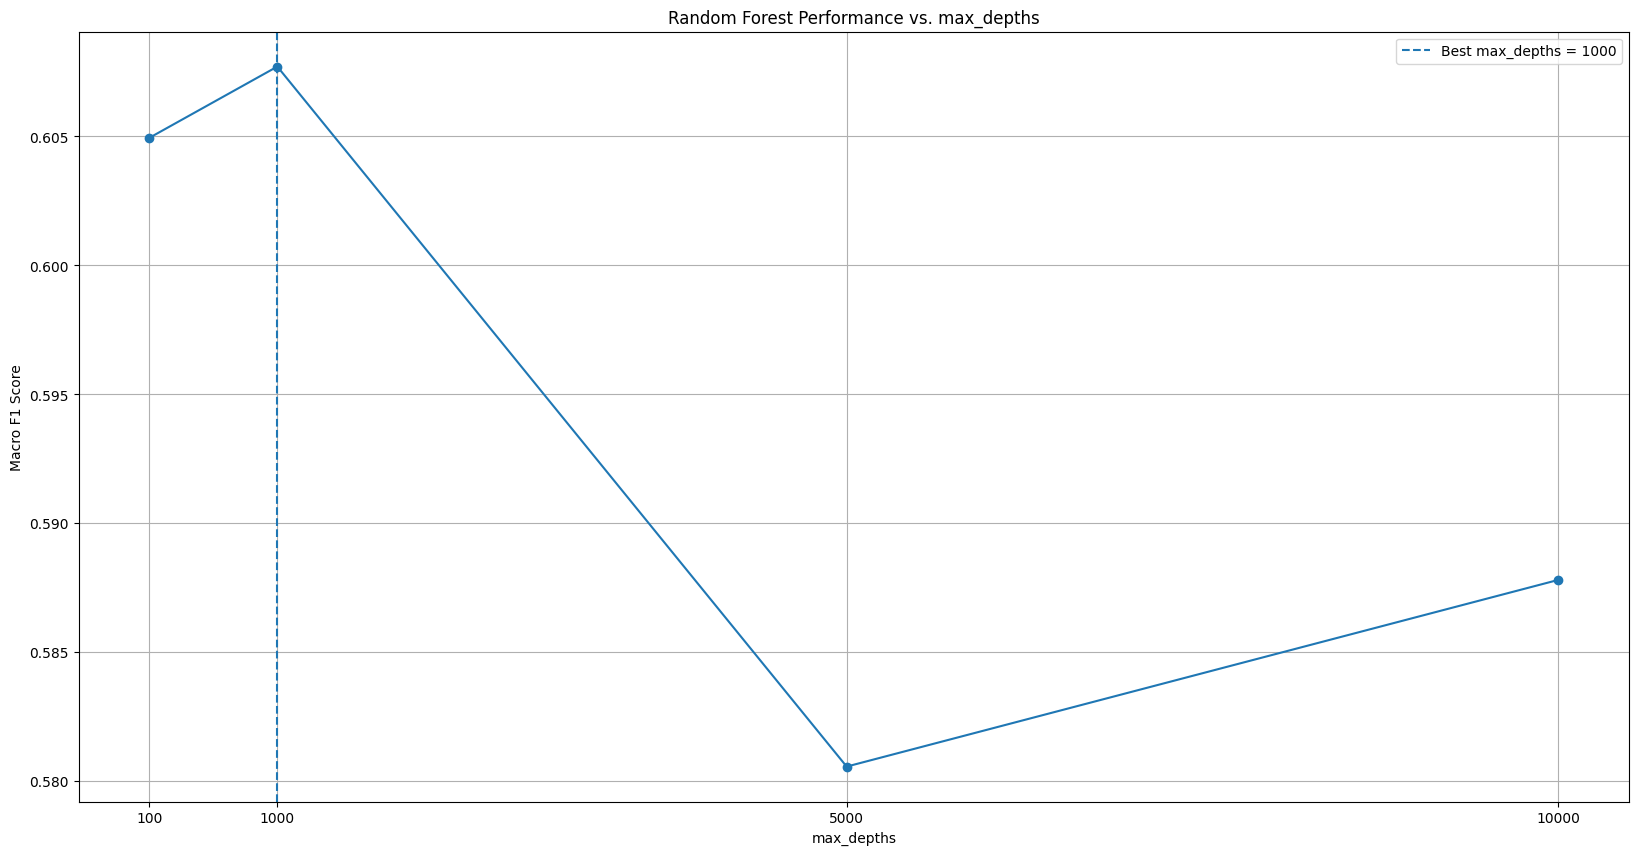

Best max_depths: 1000
Best Macro F1: 0.6077


In [ ]:
# Predicting emotion from features

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Try different k values
max_depths = [100, 1000, 5000, 10000]
macro_f1_scores = []

# Baseline model

for max_depth in max_depths:
    classifier = RandomForestClassifier(n_estimators=175, criterion="log_loss", max_depth=max_depth)
    classifier.fit(X_train, y_train)

    y_pred = classifier.predict(X_test)

    macro_f1_scores.append(
        f1_score(y_test, y_pred, average="macro")
    )

# Find best k
best_max_depths = max_depths[macro_f1_scores.index(max(macro_f1_scores))]
best_f1 = max(macro_f1_scores)

# Plot k vs performance
plt.figure(figsize=(20, 10))
plt.plot(max_depths, macro_f1_scores, marker="o")
plt.axvline(best_max_depths, linestyle="--", label=f"Best max_depths = {best_max_depths}")

plt.xlabel("max_depths")
plt.ylabel("Macro F1 Score")
plt.title("Random Forest Performance vs. max_depths")
plt.xticks(max_depths)
plt.legend()
plt.grid(True)
plt.show()

print(f"Best max_depths: {best_max_depths}")
print(f"Best Macro F1: {best_f1:.4f}")

I can't find a clear max depth that makes any meaningful difference. It's very random. Sometimes 1000 does better, other times 10000

Accuracy: 0.6109979633401222
Precision: 0.6224244531946345
Recall: 0.6039001349527665
Macro F1: 0.6069608641672415
[[52  0  6  4  9  0  1  3]
 [ 0 66  1  2  4  0  2  0]
 [ 1  4 18  0 10  0  4  2]
 [ 9  3  0 40  7  0 11  5]
 [14  6  3  5 42  0  4  1]
 [ 0  3  1  1  2 28  2  1]
 [ 1 20  3  5  6  5 34  1]
 [ 2  3  2  1  8  1  2 20]]


[Text(0.5, 0.8333333333333334, 'x[354] <= -0.168\nlog_loss = 2.908\nsamples = 1234\nvalue = [336, 292, 138, 324, 310, 137, 285, 139]'),
 Text(0.25, 0.5, 'x[208] <= -0.293\nlog_loss = 2.614\nsamples = 533\nvalue = [17.0, 255.0, 40.0, 72.0, 99.0, 125.0, 187.0, 37.0]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, '\n  (...)  \n'),
 Text(0.375, 0.16666666666666666, '\n  (...)  \n'),
 Text(0.75, 0.5, 'x[208] <= -0.172\nlog_loss = 2.607\nsamples = 701\nvalue = [319.0, 37.0, 98.0, 252.0, 211.0, 12.0, 98.0, 102.0]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, '\n  (...)  \n'),
 Text(0.875, 0.16666666666666666, '\n  (...)  \n')]

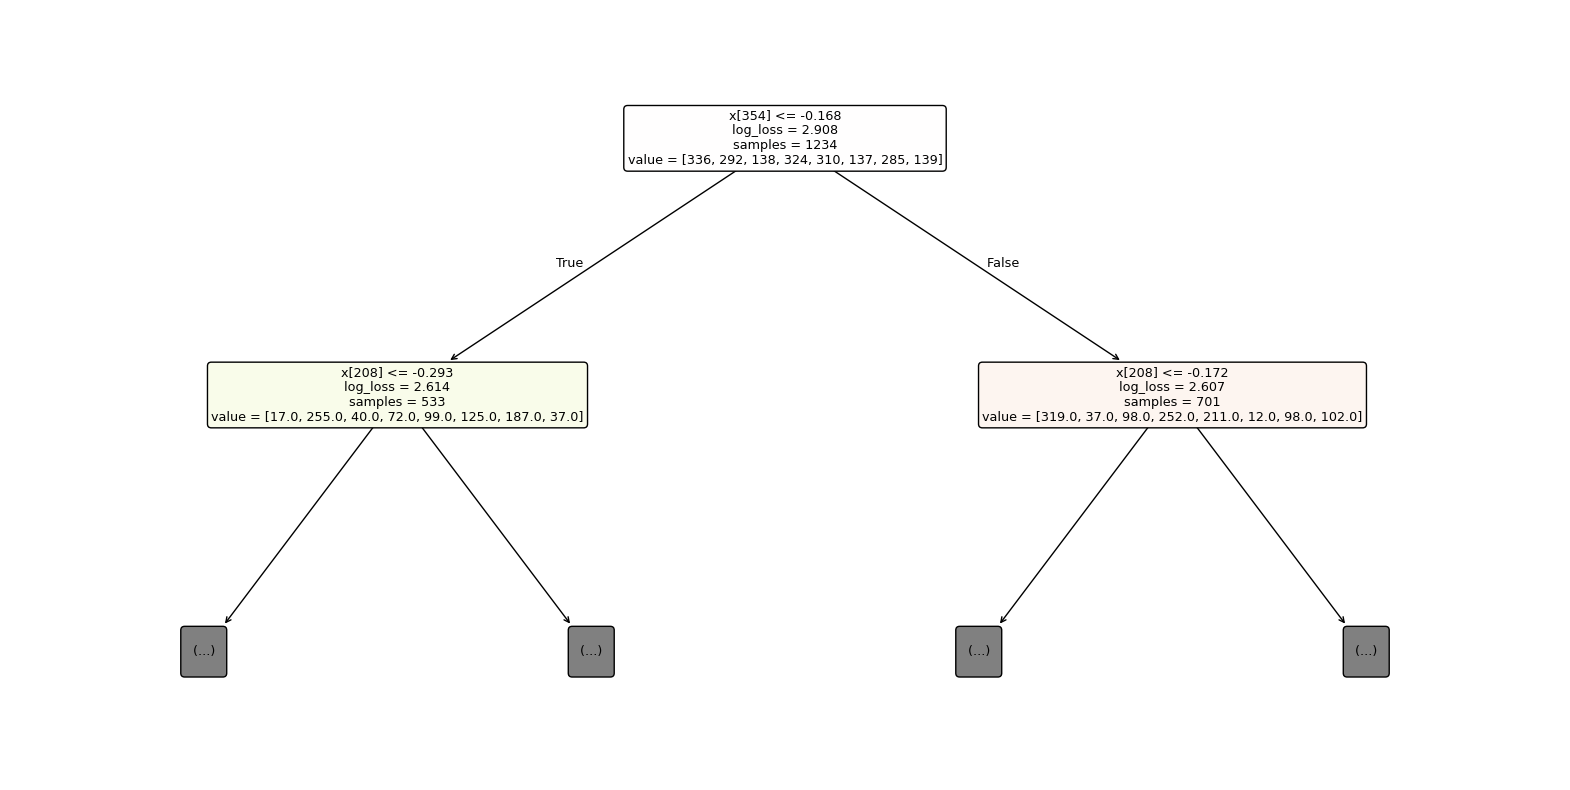

In [ ]:
# Predicting emotion from features

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Baseline model

classifier = RandomForestClassifier(n_estimators=175, criterion="log_loss")
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="macro"))
print("Recall:", recall_score(y_test, y_pred, average="macro"))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print(confusion_matrix(y_test, y_pred))

plt.figure(figsize=(20, 10))
plot_tree(classifier[0], max_depth=1, rounded=True, filled=True)

Random Forest with the best n_estimators and criterion from the sweep above gets accuracy 0.611 and macro F1 0.607. That clearly beats a single tuned decision tree (F1 0.455), which is exactly the point of bagging: averaging over many decorrelated trees reduces variance. The tree visualization at the bottom shows one of the trees in the ensemble as a sanity check. *Note: per the rubric, Random Forest is sklearn-only - only CART itself is required as a from-scratch MiniLearn implementation.*

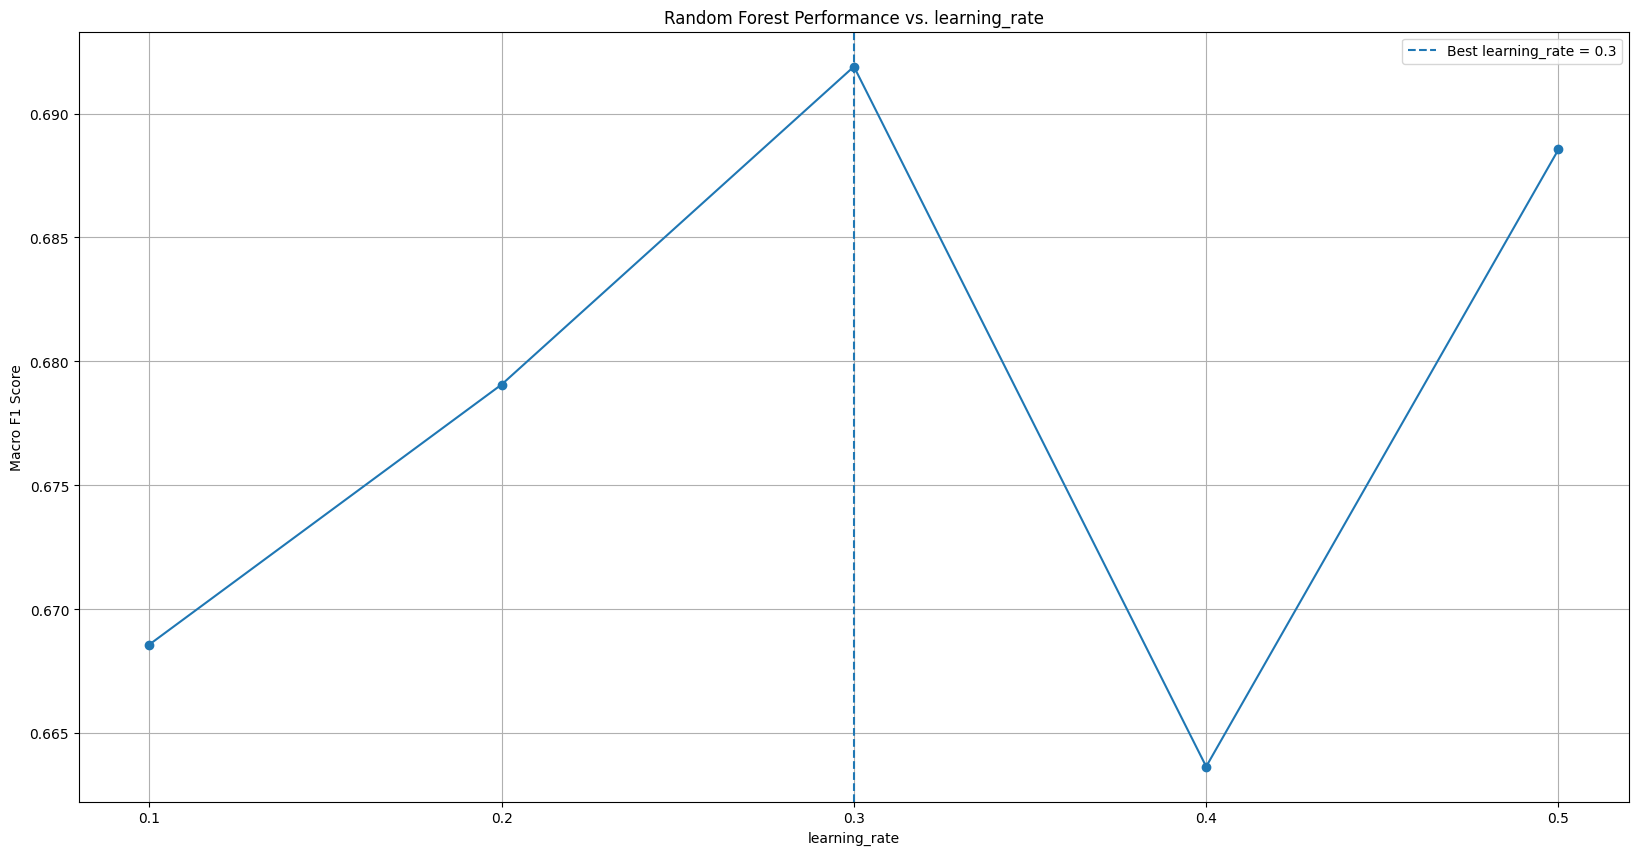

Best learning_rate: 0.3
Best Macro F1: 0.6919


In [ ]:
# Baseline model
X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

decision_tree_classifier = DecisionTreeClassifier(max_depth=11, min_samples_leaf=10, min_samples_split=51)

# Try different k values
learning_rates = [0.1, .2, .3, .4, .5]
macro_f1_scores = []

for learning_rate in learning_rates:
    adaBoost = AdaBoostClassifier(n_estimators=175, estimator=decision_tree_classifier, learning_rate=learning_rate)
    adaBoost.fit(X_train, y_train)
    y_pred = adaBoost.predict(X_test)

    macro_f1_scores.append(f1_score(y_test, y_pred, average="macro"))

# Find best k
best_learning_rate = learning_rates[macro_f1_scores.index(max(macro_f1_scores))]
best_f1 = max(macro_f1_scores)

# Plot k vs performance
plt.figure(figsize=(20, 10))
plt.plot(learning_rates, macro_f1_scores, marker="o")
plt.axvline(best_learning_rate, linestyle="--", label=f"Best learning_rate = {best_learning_rate}")

plt.xlabel("learning_rate")
plt.ylabel("Macro F1 Score")
plt.title("Random Forest Performance vs. learning_rate")
plt.xticks(learning_rates)
plt.legend()
plt.grid(True)
plt.show()

print(f"Best learning_rate: {best_learning_rate}")
print(f"Best Macro F1: {best_f1:.4f}")

.3 Is looking pretty good.

---

## 6. Model Validation and Hyperparameter Tuning

This section pulls everything together with proper Stratified K-Fold cross-validation and uses RandomizedSearchCV to tune hyperparameters for the best-performing model from earlier sections (the RBF SVM). All scaling is wrapped in a sklearn Pipeline so the scaler is refit on each training fold (no test-set leakage).

In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit Learn
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, make_scorer
from sklearn.svm import SVC
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

from minilearn.preprocessing import StandardScaler, train_test_split
from minilearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from minilearn.model_selection import KFold

In [ ]:
# load processed data
metadata = pd.read_csv("/home/westley/Documents/classes/spring_2026/machine_learning/Project_CSE432-532/SER_Project/processed_data/ravdess_metadata.csv")
features = pd.read_csv("/home/westley/Documents/classes/spring_2026/machine_learning/Project_CSE432-532/SER_Project/processed_data/ravdess_features.csv")

# load dataframes
df = metadata.merge(features, on="filename", how="inner")
features = features.drop(columns=["filename"])

In [ ]:
# Baseline model
X = features.copy()
y = df["emotion"]

models = {
    "Logistic Regression": Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=2000, random_state=42))]),

    "KNN": Pipeline([("scaler", StandardScaler()), ("model", KNeighborsClassifier(n_neighbors=30))]),

    "GNB": Pipeline([("scaler", StandardScaler()), ("model", GaussianNB())]),

    "SVC": Pipeline([("scaler", StandardScaler()), ("model", SVC(kernel="rbf", gamma=.01, C=11, random_state=42))]),

    "Decision Tree": DecisionTreeClassifier(max_depth=11, min_samples_leaf=10, min_samples_split=51, random_state=42),

    "Random Forest": RandomForestClassifier(n_estimators=175, criterion="log_loss", random_state=42),

    "Ada Boost": AdaBoostClassifier(n_estimators=175, estimator=DecisionTreeClassifier(max_depth=11, min_samples_leaf=10, min_samples_split=51, random_state=42), learning_rate=.3, random_state=42)
}

cv = KFold(n_splits=5)

results=[]
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="f1_macro")
    results.append({'Model': name, 'Mean Accuracy': scores.mean(), 'Std Dev': scores.std()})

comparison_df = pd.DataFrame(results).sort_values(by='Mean Accuracy', ascending=False)
print(comparison_df)

                 Model  Mean Accuracy   Std Dev
6            Ada Boost       0.490702  0.019443
0  Logistic Regression       0.489204  0.017737
3                  SVC       0.467587  0.028831
5        Random Forest       0.454107  0.034295
1                  KNN       0.391505  0.011172
4        Decision Tree       0.327846  0.024345
2                  GNB       0.243303  0.044743


Cross-validated comparison of all the classical models using 5-fold CV with macro F1 scoring. AdaBoost (0.491) and Logistic Regression (0.489) come out on top, followed by SVC (0.468), Random Forest (0.454), kNN (0.392), Decision Tree (0.328), and GNB last at 0.243. Note the CV averages are lower than the held-out scores I was getting in earlier sections, which is the usual story: a single 80/20 train/test split flatters the numbers somewhat.

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
# Baseline model
X = features.copy()
y = df["emotion"]

models = {
    "Logistic Regression": Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=2000, random_state=42))]),

    "KNN": Pipeline([("scaler", StandardScaler()), ("model", KNeighborsClassifier(n_neighbors=30))]),

    "GNB": Pipeline([("scaler", StandardScaler()), ("model", GaussianNB())]),

    "SVC": Pipeline([("scaler", StandardScaler()), ("model", SVC(kernel="rbf", gamma=.01, C=11, random_state=42))]),

    "Decision Tree": DecisionTreeClassifier(max_depth=11, min_samples_leaf=10, min_samples_split=51, random_state=42),

    "Random Forest": RandomForestClassifier(n_estimators=175, criterion="log_loss", random_state=42),

    "Ada Boost": AdaBoostClassifier(n_estimators=175, estimator=DecisionTreeClassifier(max_depth=11, min_samples_leaf=10, min_samples_split=51, random_state=42), learning_rate=.3, random_state=42)
}

cv = KFold(n_splits=5)

results=[]
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="f1_macro")
    results.append({'Model': name, 'Mean Accuracy': scores.mean(), 'Std Dev': scores.std()})

comparison_df = pd.DataFrame(results).sort_values(by='Mean Accuracy', ascending=False)
print(comparison_df)

                 Model  Mean Accuracy   Std Dev
6            Ada Boost       0.490702  0.019443
0  Logistic Regression       0.489204  0.017737
3                  SVC       0.467587  0.028831
5        Random Forest       0.454107  0.034295
1                  KNN       0.391505  0.011172
4        Decision Tree       0.327846  0.024345
2                  GNB       0.243303  0.044743


Same comparison rerun with the additional imports needed to make the cell stand alone. Numbers match the previous cell exactly. This is the version I'd reach for in a final report since it doesn't depend on previously-executed cells for setup.

In [ ]:
pipeline = Pipeline([("scaler", StandardScaler()), ("model", SVC())])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

parameter_distributions = {"model__C": loguniform(1e0, 1e2), "model__gamma": loguniform(1e-4, 1e0), "model__kernel": ["rbf"]}

random_search = RandomizedSearchCV(estimator=pipeline, param_distributions=parameter_distributions, scoring="f1_macro", n_jobs=-1, cv=5, n_iter=50, random_state=42)

random_search.fit(X_train, y_train)

print(random_search.best_params_)
print(random_search.best_score_)

best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)

print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

{'model__C': np.float64(45.44383960336016), 'model__gamma': np.float64(0.0026730883107816713), 'model__kernel': 'rbf'}
0.6853716636926936
Macro F1: 0.6912342207949111
Accuracy: 0.6965376782077393
[[59  0  4  3  4  0  3  2]
 [ 0 60  2  2  5  0  6  0]
 [ 4  2 23  0  0  1  3  6]
 [11  3  2 45  6  1  5  2]
 [ 7  3  0  7 52  2  3  1]
 [ 0  1  0  1  1 32  3  0]
 [ 3  7  3  6  3  1 50  2]
 [ 4  2  5  4  2  0  1 21]]


RandomizedSearchCV on the best-performing kernel (RBF SVC) with C sampled log-uniformly between 1 and 100 and gamma between 1e-4 and 1. Fifty iterations of 5-fold CV. Best params come out as C around 45.4 and gamma around 0.0027, with a test macro F1 of 0.691 and accuracy of 0.697. The confusion matrix shows neutral and angry being among the easier classes; disgust is the hardest.

---

## 7. Clustering (K-Means)

Time to leave supervised learning behind for a bit. The question here is: if I cluster the audio features with K-Means (k = 8 to match the number of emotions), do the resulting clusters line up with the true emotion labels at all?

I evaluate this with Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI), and visualize the result with t-SNE colored by cluster assignment versus true emotion. I run K-Means in both MiniLearn and scikit-learn.

In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit Learn
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, make_scorer, silhouette_score
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

In [ ]:
# load processed data
metadata = pd.read_csv("/home/westley/Documents/classes/spring_2026/machine_learning/Project_CSE432-532/SER_Project/processed_data/ravdess_metadata.csv")
features = pd.read_csv("/home/westley/Documents/classes/spring_2026/machine_learning/Project_CSE432-532/SER_Project/processed_data/ravdess_features.csv")

# load dataframes
df = metadata.merge(features, on="filename", how="inner")
features = features.drop(columns=["filename"])

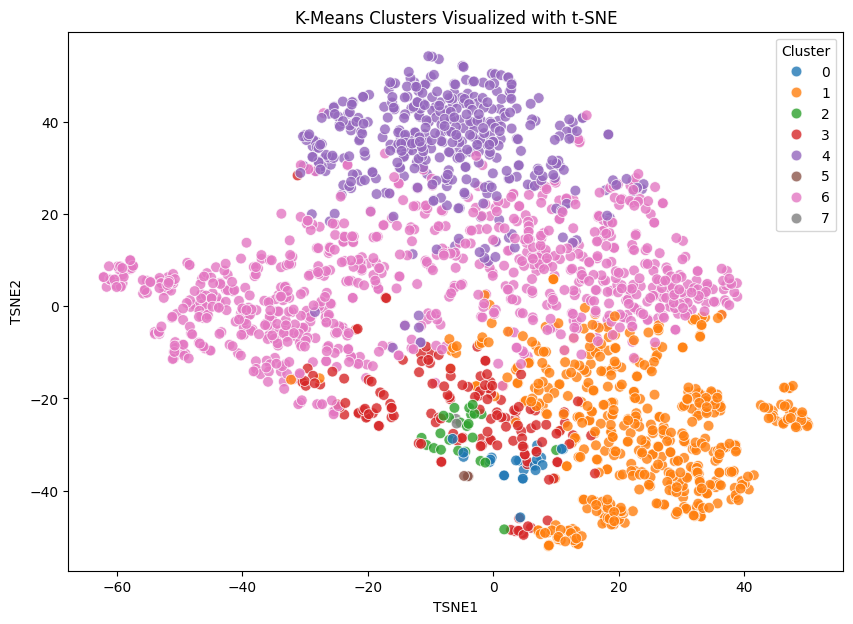

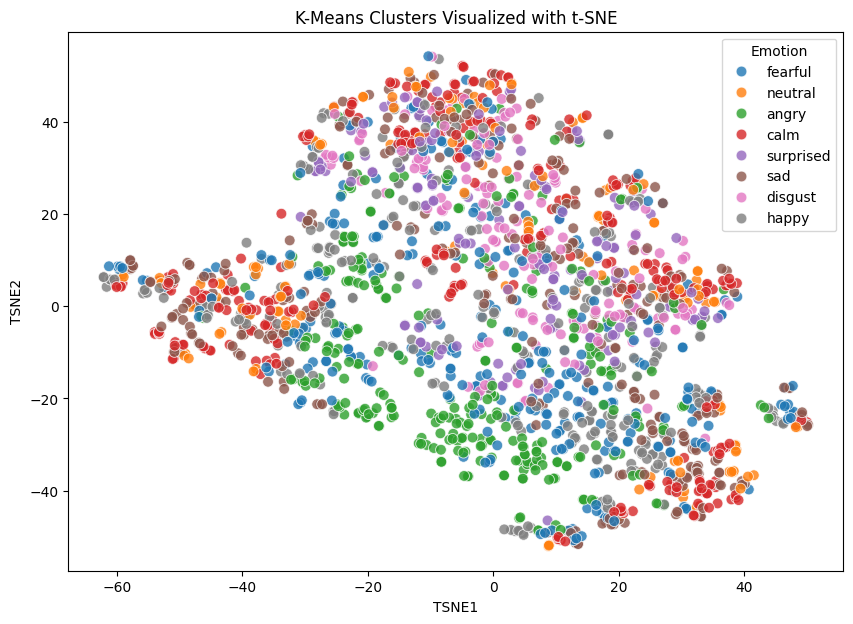

In [ ]:
from minilearn.cluster import KMeans
X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


cluster = KMeans(n_clusters=8)
labels = cluster.fit_predict(X_train_scaled)

plotable = TSNE(n_components=2, random_state=42).fit_transform(X_train_scaled)


plot_df = pd.DataFrame({"TSNE1": plotable[:, 0], "TSNE2": plotable[:, 1], "Cluster": labels, "Emotion": y_train.values})

plt.figure(figsize=(10, 7))
sns.scatterplot(data=plot_df, x="TSNE1", y="TSNE2", hue="Cluster", palette="tab10", s=60, alpha=0.8)
plt.title("K-Means Clusters Visualized with t-SNE")
plt.show()

plt.figure(figsize=(10, 7))
sns.scatterplot(data=plot_df, x="TSNE1", y="TSNE2", hue="Emotion", palette="tab10", s=60, alpha=0.8)
plt.title("Emotion Visualized with t-SNE")
plt.show()

**MiniLearn run.** K-Means with k=8 on the standardized features using MiniLearn. The first t-SNE plot colors points by predicted cluster; the second by true emotion. If the clusters tracked emotion well the two plots would look similar. They don't really, which is the main finding of the clustering section.

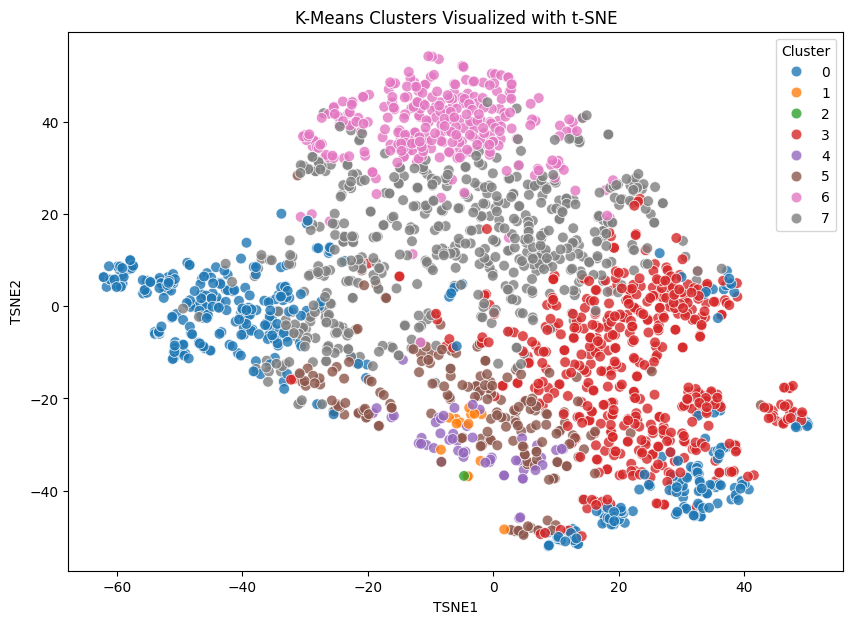

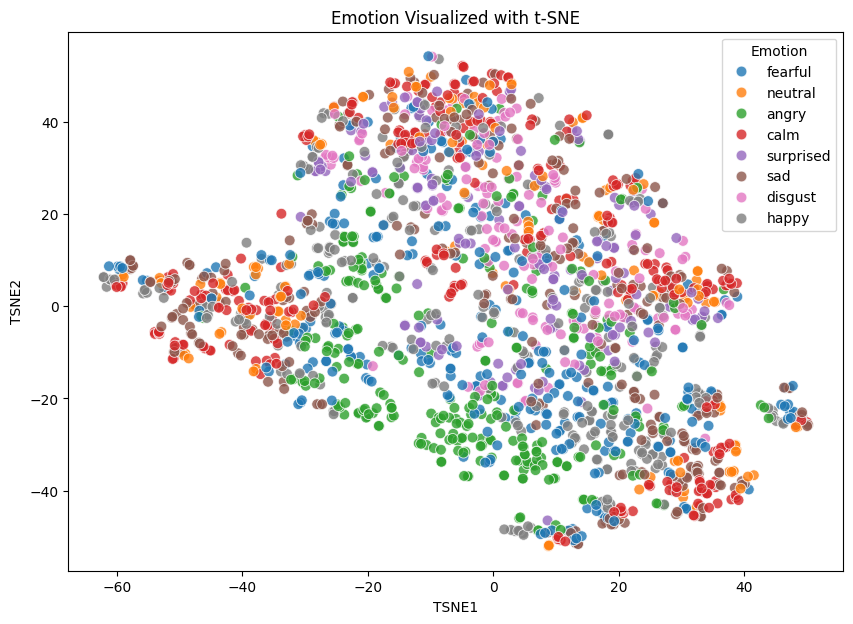

In [ ]:
from sklearn.cluster import KMeans
X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


cluster = KMeans(n_clusters=8)
labels = cluster.fit_predict(X_train_scaled)

plotable = TSNE(n_components=2, random_state=42).fit_transform(X_train_scaled)


plot_df = pd.DataFrame({"TSNE1": plotable[:, 0], "TSNE2": plotable[:, 1], "Cluster": labels, "Emotion": y_train.values})

plt.figure(figsize=(10, 7))
sns.scatterplot(data=plot_df, x="TSNE1", y="TSNE2", hue="Cluster", palette="tab10", s=60, alpha=0.8)
plt.title("K-Means Clusters Visualized with t-SNE")
plt.show()

plt.figure(figsize=(10, 7))
sns.scatterplot(data=plot_df, x="TSNE1", y="TSNE2", hue="Emotion", palette="tab10", s=60, alpha=0.8)
plt.title("Emotion Visualized with t-SNE")
plt.show()

**scikit-learn check.** Same setup with sklearn's KMeans. The cluster geometry looks comparable to MiniLearn's run above, and crucially the same problem appears: the natural clusters don't correspond to emotion labels in any obvious way. This is expected. Emotion is a relatively small signal compared to speaker identity and acoustic content variation in these features.

In [ ]:
X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


scores = []

for k in range(2, 20):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_train_scaled)

    score = silhouette_score(X_train_scaled, labels)
    scores.append(score)

    print(k, score)

2 0.6707724642205796
3 0.5154698461676163
4 0.09227536376937225
5 0.07916341274786709
6 0.07870528690738615
7 0.07906266304388457
8 0.06275117340691722
9 0.06305539921852779
10 0.06261853673048819
11 0.06415421946357654
12 0.06375507677207602
13 0.06333520111176755
14 0.06384443341742471
15 0.06250252197714194
16 0.05836120148800109
17 0.05682835005095899
18 0.05701725588468749
19 0.05551281688383189


Sweeping k from 2 to 19 with silhouette score. The clear winner is k=2 at silhouette 0.67, with a big dropoff to about 0.52 at k=3 and then a long plateau around 0.06 from k=8 onward. This is a strong hint that the dominant clustering structure in the features is binary (likely speaker gender, given how easily the gender classifier separated them earlier). For our k=8 target, the silhouette is essentially no cluster cohesion.

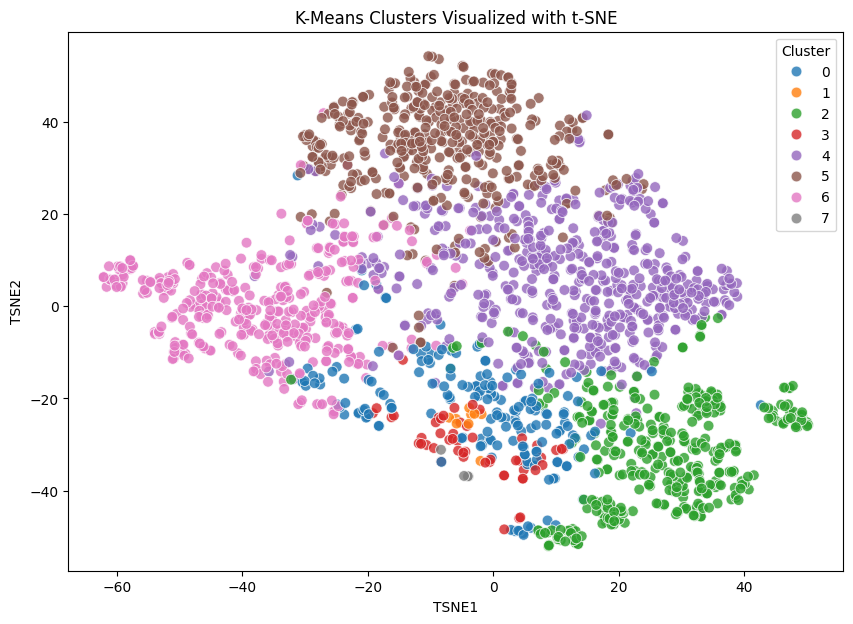

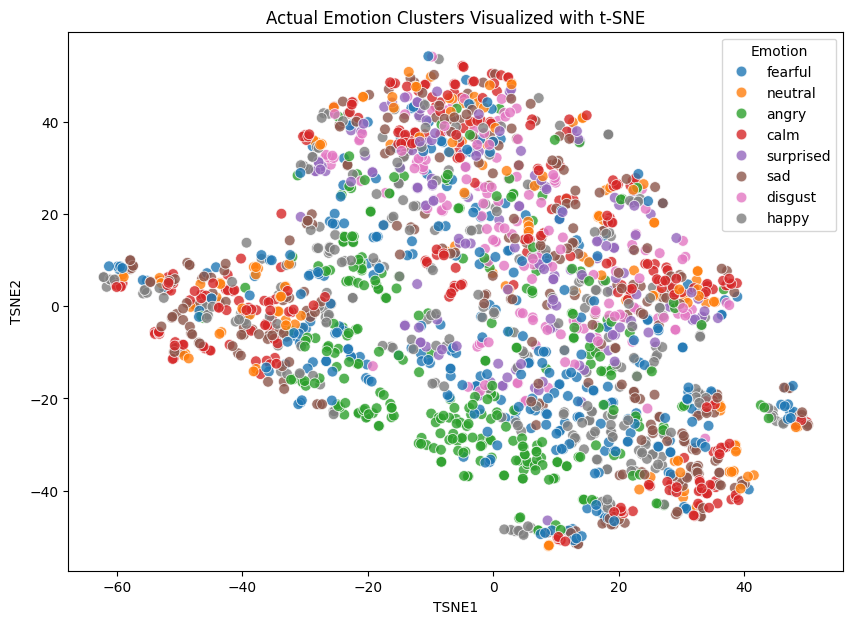

In [ ]:
X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


cluster = KMeans(n_clusters=8, random_state=42)
labels = cluster.fit_predict(X_train_scaled)

plotable = TSNE(n_components=2, random_state=42).fit_transform(X_train_scaled)


plot_df = pd.DataFrame({"TSNE1": plotable[:, 0], "TSNE2": plotable[:, 1], "Cluster": labels, "Emotion": y_train.values})

plt.figure(figsize=(10, 7))
sns.scatterplot(data=plot_df, x="TSNE1", y="TSNE2", hue="Cluster", palette="tab10", s=60, alpha=0.8)
plt.title("K-Means Clusters Visualized with t-SNE")
plt.show()

plt.figure(figsize=(10, 7))
sns.scatterplot(data=plot_df, x="TSNE1", y="TSNE2", hue="Emotion", palette="tab10", s=60, alpha=0.8)
plt.title("Actual Emotion Clusters Visualized with t-SNE")
plt.show()

Final K-Means run with k=8 and random_state set for reproducibility. The t-SNE plots tell the same story as the runs above. Without labels to guide it, K-Means finds whatever structure has the largest variance, and that structure isn't emotion.

---

## 8. Dimensionality Reduction (PCA)

PCA is used here both for visualization (project the standardized features onto 2 components) and as a preprocessing step before classification (project onto enough components to explain 80%, 90%, or 95% of the variance, then re-run the best classifier). The MiniLearn PCA implementation is compared against scikit-learn's, and the explained-variance curve is plotted to motivate the choice of components.

In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit Learn
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, make_scorer, silhouette_score, classification_report
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

In [ ]:
# load processed data
metadata = pd.read_csv("/home/westley/Documents/classes/spring_2026/machine_learning/Project_CSE432-532/SER_Project/processed_data/ravdess_metadata.csv")
features = pd.read_csv("/home/westley/Documents/classes/spring_2026/machine_learning/Project_CSE432-532/SER_Project/processed_data/ravdess_features.csv")

# load dataframes
df = metadata.merge(features, on="filename", how="inner")
features = features.drop(columns=["filename"])


PC1 top features:
rms_std         0.086801
mel_103_mean    0.084225
rms_mean        0.083967
mel_120_mean    0.083700
mel_104_mean    0.083394
mel_121_mean    0.082888
mel_119_mean    0.082837
mel_102_mean    0.081520
mel_115_mean    0.081417
mel_122_mean    0.081335
Name: PC1, dtype: float64

PC2 top features:
chroma_4_mean     0.175738
chroma_3_mean     0.175419
chroma_8_mean     0.172581
chroma_2_mean     0.170026
chroma_9_mean     0.168376
mfcc_6_mean       0.166062
mfcc_7_mean       0.165432
chroma_10_mean    0.160860
mfcc_10_mean      0.159084
chroma_11_mean    0.155132
Name: PC2, dtype: float64

PC3 top features:
mel_111_std     0.125214
mel_110_std     0.120089
mel_109_std     0.120014
mel_117_std     0.118392
mel_112_std     0.117347
mel_110_mean    0.117066
mel_116_std     0.116211
mel_111_mean    0.115288
mel_118_std     0.113012
mel_113_std     0.111997
Name: PC3, dtype: float64

PC4 top features:
mel_6_mean       0.185909
mel_6_std        0.184458
mel_5_mean       0.17588

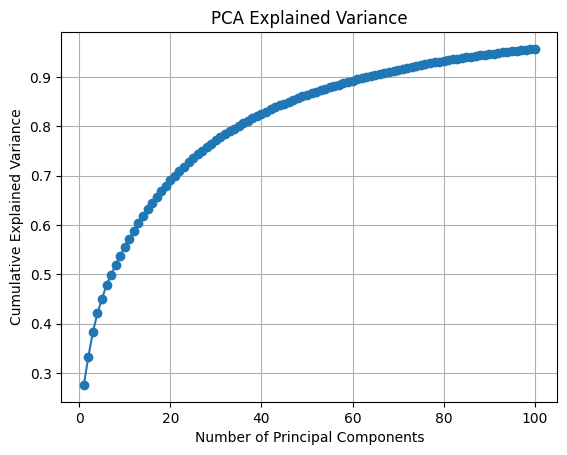

In [ ]:
X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


pca = PCA(n_components=100).fit(X_train_scaled)

components_df = pd.DataFrame(pca.components_, columns=X.columns, index=[f"PC{i+1}" for i in range(pca.n_components_)])


for pc in components_df.index:
    print(f"\n{pc} top features:")
    print(components_df.loc[pc].abs().sort_values(ascending=False).head(10))

cum_var = np.cumsum(pca.explained_variance_ratio_)

for i, v in enumerate(cum_var, start=1):
    print(f"{i} components explain {v:.2%} of variance")

plt.plot(range(1, 101), np.cumsum(pca.explained_variance_ratio_),marker="o")

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()

PCA with 100 components fit on the standardized features. The printed top features per component are informative: PC1 is dominated by rms and mel features (overall energy), PC2 by chroma features (tonal content), PC3 by mel std features (spectral variability). The cumulative explained variance plot at the bottom shows we need ~93 components to reach 95% variance - the signal is spread across many dimensions, not concentrated in a few.


PC1 top features:
rms_std         0.086801
mel_103_mean    0.084225
rms_mean        0.083967
mel_120_mean    0.083700
mel_104_mean    0.083394
mel_121_mean    0.082888
mel_119_mean    0.082837
mel_102_mean    0.081520
mel_115_mean    0.081417
mel_122_mean    0.081335
Name: PC1, dtype: float64

PC2 top features:
chroma_4_mean     0.175738
chroma_3_mean     0.175419
chroma_8_mean     0.172581
chroma_2_mean     0.170026
chroma_9_mean     0.168376
mfcc_6_mean       0.166062
mfcc_7_mean       0.165432
chroma_10_mean    0.160860
mfcc_10_mean      0.159084
chroma_11_mean    0.155132
Name: PC2, dtype: float64

PC3 top features:
mel_111_std     0.125214
mel_110_std     0.120089
mel_109_std     0.120014
mel_117_std     0.118392
mel_112_std     0.117347
mel_110_mean    0.117066
mel_116_std     0.116211
mel_111_mean    0.115288
mel_118_std     0.113012
mel_113_std     0.111997
Name: PC3, dtype: float64

PC4 top features:
mel_6_mean       0.185909
mel_6_std        0.184458
mel_5_mean       0.17588

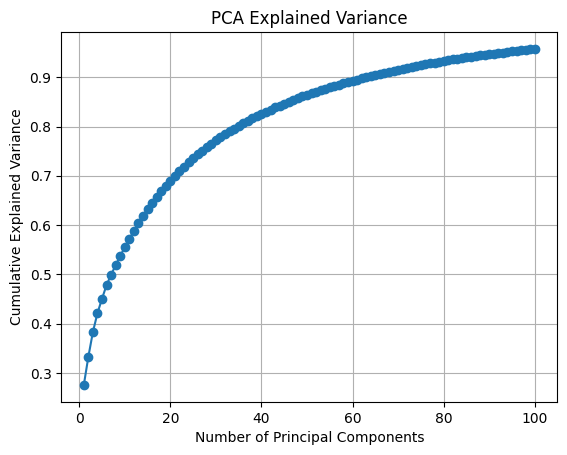

In [ ]:
from minilearn.decomposition import PCA
X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


pca = PCA(n_components=100).fit(X_train_scaled)

components_df = pd.DataFrame(pca.components_, columns=X.columns, index=[f"PC{i+1}" for i in range(pca.n_components_)])


for pc in components_df.index:
    print(f"\n{pc} top features:")
    print(components_df.loc[pc].abs().sort_values(ascending=False).head(10))

cum_var = np.cumsum(pca.explained_variance_ratio_)

for i, v in enumerate(cum_var, start=1):
    print(f"{i} components explain {v:.2%} of variance")

plt.plot(range(1, 101), np.cumsum(pca.explained_variance_ratio_),marker="o")

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()

**MiniLearn vs scikit-learn check.** MiniLearn's PCA on the same data. The cumulative variance curve matches sklearn's almost exactly (within rounding in the third decimal place) and the top contributing features per principal component line up. The from-scratch eigendecomposition is working correctly.

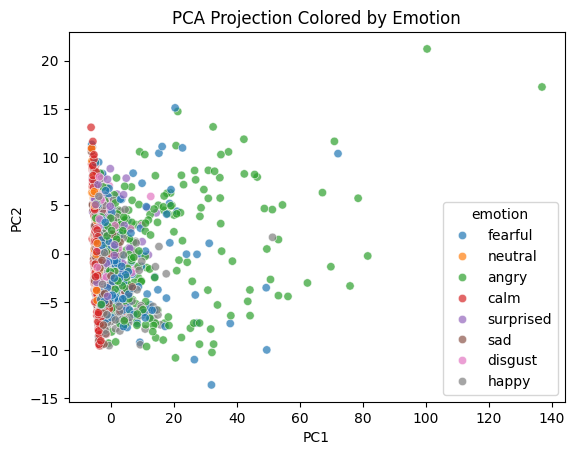

In [ ]:
pca_2 = PCA(n_components=2)
X_train_pca_2 = pca_2.fit_transform(X_train_scaled)

pca_plot_df = pd.DataFrame({
    "PC1": X_train_pca_2[:, 0],
    "PC2": X_train_pca_2[:, 1],
    "emotion": y_train.values
})

sns.scatterplot(
    data=pca_plot_df,
    x="PC1",
    y="PC2",
    hue="emotion",
    alpha=0.7
)

plt.title("PCA Projection Colored by Emotion")
plt.show()

Projecting onto just the top 2 principal components and coloring by emotion. The emotions don't cleanly separate in this 2D projection, which is consistent with the clustering result. The classifier uses many more than 2 dimensions, but this is a useful sanity check on how mixed the data is in the high-variance directions.

In [ ]:
X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


pca = PCA(n_components=.9).fit(X_train_scaled)

components_df = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=[f"PC{i+1}" for i in range(pca.n_components_)]
)


for pc in components_df.index:
    print(f"\n{pc} top features:")
    print(
        components_df.loc[pc]
        .abs()
        .sort_values(ascending=False)
        .head(10)
    )

cum_var = np.cumsum(pca.explained_variance_ratio_)

for i, v in enumerate(cum_var, start=1):
    print(f"{i} components explain {v:.2%} of variance")


PC1 top features:
rms_std         0.086801
mel_103_mean    0.084225
rms_mean        0.083967
mel_120_mean    0.083700
mel_104_mean    0.083394
mel_121_mean    0.082888
mel_119_mean    0.082837
mel_102_mean    0.081520
mel_115_mean    0.081417
mel_122_mean    0.081335
Name: PC1, dtype: float64

PC2 top features:
chroma_4_mean     0.175738
chroma_3_mean     0.175419
chroma_8_mean     0.172581
chroma_2_mean     0.170026
chroma_9_mean     0.168376
mfcc_6_mean       0.166062
mfcc_7_mean       0.165432
chroma_10_mean    0.160860
mfcc_10_mean      0.159084
chroma_11_mean    0.155132
Name: PC2, dtype: float64

PC3 top features:
mel_111_std     0.125214
mel_110_std     0.120089
mel_109_std     0.120014
mel_117_std     0.118392
mel_112_std     0.117347
mel_110_mean    0.117066
mel_116_std     0.116211
mel_111_mean    0.115288
mel_118_std     0.113012
mel_113_std     0.111997
Name: PC3, dtype: float64

PC4 top features:
mel_6_mean       0.185909
mel_6_std        0.184458
mel_5_mean       0.17588

Asking PCA to retain 90% of the variance directly instead of specifying a number of components. It picks about 63 components to do that. Useful for understanding compressibility of the feature space: roughly a 6x reduction in dimensionality is possible without losing 10% of the variance.

In [ ]:
for variance in [0.80, 0.90, 0.95]:
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=variance)),
        ("model", SVC(kernel="rbf"))
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    print(f"\nPCA variance: {variance}")
    print("Components:", pipeline.named_steps["pca"].n_components_)
    print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
    print("Accuracy:", accuracy_score(y_test, y_pred))

    pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf"))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("No PCA")
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("Accuracy:", accuracy_score(y_test, y_pred))


PCA variance: 0.8
Components: 35
Macro F1: 0.3687281562901384
Accuracy: 0.41140529531568226

PCA variance: 0.9
Components: 63
Macro F1: 0.44607288994229316
Accuracy: 0.48268839103869654

PCA variance: 0.95
Components: 93
Macro F1: 0.5212075107637585
Accuracy: 0.5356415478615071
No PCA
Macro F1: 0.5668103811190435
Accuracy: 0.5784114052953157


PCA performs pretty poorly

In [ ]:
X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pipeline = Pipeline([("scaler", StandardScaler()), ("pca", PCA()), ("model", SVC(kernel="rbf"))])

param_dist = {"pca__n_components": [0.80, 0.85, 0.90, 0.95, 0.99, 20, 30, 40, 50, 60, 70, 80], "model__C": loguniform(1e-2, 1e2), "model__gamma": loguniform(1e-4, 1e0),}

search = RandomizedSearchCV(pipeline, param_distributions=param_dist, n_iter=60, scoring="f1_macro", cv=5, random_state=42, n_jobs=-1)

search.fit(X_train, y_train)

best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

print("Best params:", search.best_params_)
print("CV macro F1:", search.best_score_)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test macro F1:", f1_score(y_test, y_pred, average="macro"))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Best params: {'model__C': np.float64(3.14351974471359), 'model__gamma': np.float64(0.0015224209209544581), 'pca__n_components': 0.99}
CV macro F1: 0.6130894688569906
Test accuracy: 0.6211812627291242
Test macro F1: 0.6104844244390795
[[54  0  3  3  8  0  3  4]
 [ 0 57  1  2  5  0 10  0]
 [ 4  4 17  2  2  1  2  7]
 [ 6  5  1 49  6  0  7  1]
 [ 8  8  1  7 44  0  5  2]
 [ 0  3  1  1  0 23  8  2]
 [ 1 13  5  3  7  1 42  3]
 [ 4  4  3  3  4  1  1 19]]
              precision    recall  f1-score   support

       angry       0.70      0.72      0.71        75
        calm       0.61      0.76      0.67        75
     disgust       0.53      0.44      0.48        39
     fearful       0.70      0.65      0.68        75
       happy       0.58      0.59      0.58        75
     neutral       0.88      0.61      0.72        38
         sad       0.54      0.56      0.55        75
   surprised       0.50      0.49      0.49        39

    accuracy                           0.62       491
   macr

With the features reduced, the model performs worse

In [ ]:
X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pipeline = Pipeline([("scaler", StandardScaler()), ("lda", LinearDiscriminantAnalysis()), ("model", SVC(kernel="rbf"))])

param_dist = {"lda__n_components": [1, 2, 3, 4, 5, 6, 7], "model__C": loguniform(1e-2, 1e2), "model__gamma": loguniform(1e-4, 1e0),}

search = RandomizedSearchCV(pipeline, param_distributions=param_dist, n_iter=40, scoring="f1_macro", cv=5, random_state=42, n_jobs=-1)

search.fit(X_train, y_train)

best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

print("Best params:", search.best_params_)
print("CV macro F1:", search.best_score_)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test macro F1:", f1_score(y_test, y_pred, average="macro"))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Best params: {'lda__n_components': 7, 'model__C': np.float64(15.352246941973492), 'model__gamma': np.float64(0.000541675458324746)}
CV macro F1: 0.5788856559610343
Test accuracy: 0.6028513238289206
Test macro F1: 0.6046446184091179
[[32  2  5 10 11  1  6  8]
 [ 0 57  2  1  5  1  9  0]
 [ 2  2 25  0  1  0  5  4]
 [ 4  3  4 49  5  0  6  4]
 [ 3  6  5 10 44  1  4  2]
 [ 0  2  0  0  3 26  6  1]
 [ 1 17  4  5  4  0 43  1]
 [ 4  3  4  2  4  0  2 20]]
              precision    recall  f1-score   support

       angry       0.70      0.43      0.53        75
        calm       0.62      0.76      0.68        75
     disgust       0.51      0.64      0.57        39
     fearful       0.64      0.65      0.64        75
       happy       0.57      0.59      0.58        75
     neutral       0.90      0.68      0.78        38
         sad       0.53      0.57      0.55        75
   surprised       0.50      0.51      0.51        39

    accuracy                           0.60       491
   macro 

Trying LDA instead of PCA in the pipeline. Unlike PCA which is unsupervised, LDA uses the labels to find directions that maximize class separation, so in theory it should be more useful for classification. Best result here is macro F1 0.605, still below the full-feature SVM (0.69). LDA is capped at (n_classes - 1) = 7 components, which may be too aggressive a reduction for this problem.

In [ ]:
X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pipeline = Pipeline([("scaler", StandardScaler()), ("select", SelectKBest(score_func=mutual_info_classif)), ("model", SVC(kernel="rbf"))])

parameter_distributions = {"select__k": [10, 20, 30, 40, 50, 60, 70, 80, "all"], "model__C": loguniform(1e0, 1e2), "model__gamma": loguniform(1e-4, 1e0), "model__kernel": ["rbf"]}

search = RandomizedSearchCV(estimator=pipeline, param_distributions=parameter_distributions, scoring="f1_macro", n_jobs=-1, cv=5, n_iter=50, random_state=42)

search.fit(X_train, y_train)

best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

print("Best params:", search.best_params_)
print("CV macro F1:", search.best_score_)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test macro F1:", f1_score(y_test, y_pred, average="macro"))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

selected_mask = best_model.named_steps["select"].get_support()
selected_features = X.columns[selected_mask]

print("Selected features:")
print(selected_features.tolist())

Best params: {'model__C': np.float64(4.059611610484305), 'model__gamma': np.float64(0.012561043700013555), 'model__kernel': 'rbf', 'select__k': 'all'}
CV macro F1: 0.6379511555765858
Test accuracy: 0.6924643584521385
Test macro F1: 0.6895908501653476
[[66  0  2  2  3  0  1  1]
 [ 2 56  1  5  5  0  6  0]
 [10  2 16  2  0  0  4  5]
 [17  2  1 49  3  0  2  1]
 [16  3  0  6 46  1  2  1]
 [ 1  1  0  3  0 32  1  0]
 [ 2 10  2  4  2  0 52  3]
 [ 8  2  2  1  3  0  0 23]]
              precision    recall  f1-score   support

       angry       0.54      0.88      0.67        75
        calm       0.74      0.75      0.74        75
     disgust       0.67      0.41      0.51        39
     fearful       0.68      0.65      0.67        75
       happy       0.74      0.61      0.67        75
     neutral       0.97      0.84      0.90        38
         sad       0.76      0.69      0.73        75
   surprised       0.68      0.59      0.63        39

    accuracy                           0.69 

I can't find a way to reduce features while retaining model performance, currently.

---

## 9. Neural Network (MLP)

Finally, a neural network. I implement a small multi-layer perceptron from scratch in MiniLearn and compare it against scikit-learn's `MLPClassifier`. This is the most flexible model in the project, and in principle should outperform the classical models, though as we'll see the gap on this dataset and feature set turns out to be smaller than expected.

In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit Learn
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, make_scorer, silhouette_score, classification_report
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.neural_network import MLPClassifier

In [ ]:
# load processed data
metadata = pd.read_csv("/home/westley/Documents/classes/spring_2026/machine_learning/Project_CSE432-532/SER_Project/processed_data/ravdess_metadata.csv")
features = pd.read_csv("/home/westley/Documents/classes/spring_2026/machine_learning/Project_CSE432-532/SER_Project/processed_data/ravdess_features.csv")

# load dataframes
df = metadata.merge(features, on="filename", how="inner")
features = features.drop(columns=["filename"])

In [ ]:
X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

MLP = MLPClassifier().fit(X_train_scaled, y_train)

y_pred = MLP.predict(X_test_scaled)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test Macro F1:", f1_score(y_test, y_pred, average="macro"))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Test Accuracy: 0.6782077393075356
Test Macro F1: 0.6777416692629477
              precision    recall  f1-score   support

       angry       0.70      0.69      0.70        75
        calm       0.72      0.75      0.73        75
     disgust       0.64      0.54      0.58        39
     fearful       0.67      0.65      0.66        75
       happy       0.70      0.64      0.67        75
     neutral       0.80      0.87      0.84        38
         sad       0.60      0.67      0.63        75
   surprised       0.62      0.62      0.62        39

    accuracy                           0.68       491
   macro avg       0.68      0.68      0.68       491
weighted avg       0.68      0.68      0.68       491

[[52  0  4  3  8  1  3  4]
 [ 0 56  1  2  4  0 12  0]
 [ 4  1 21  2  2  1  3  5]
 [ 6  4  1 49  4  0  8  3]
 [ 7  5  0  7 48  2  5  1]
 [ 0  1  1  0  1 33  2  0]
 [ 1  9  1  7  1  4 50  2]
 [ 4  2  4  3  1  0  1 24]]


/home/westley/Documents/classes/spring_2026/machine_learning/Project_CSE432-532/SER_Project/.venv/lib64/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Vanilla MLP with all defaults. Even untuned it gets accuracy 0.678 and macro F1 0.678, already competitive with the tuned RBF SVM (F1 0.705) from earlier. The per-class classification report shows neutral and calm are easiest, disgust is hardest.

In [ ]:
from minilearn.neural_network import MLPClassifier

X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

MLP = MLPClassifier(max_iter=1000).fit(X_train_scaled, y_train)

y_pred = MLP.predict(X_test_scaled)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test Macro F1:", f1_score(y_test, y_pred, average="macro"))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Test Accuracy: 0.5682281059063137
Test Macro F1: 0.5549030683531462
              precision    recall  f1-score   support

       angry       0.63      0.64      0.64        75
        calm       0.63      0.79      0.70        75
     disgust       0.54      0.38      0.45        39
     fearful       0.62      0.56      0.59        75
       happy       0.48      0.59      0.53        75
     neutral       0.67      0.53      0.59        38
         sad       0.47      0.43      0.45        75
   surprised       0.51      0.49      0.50        39

    accuracy                           0.57       491
   macro avg       0.57      0.55      0.55       491
weighted avg       0.57      0.57      0.56       491

[[48  0  3  3 15  1  1  4]
 [ 0 59  0  1  5  0  9  1]
 [ 6  3 15  3  2  2  3  5]
 [ 9  1  1 42  8  2  8  4]
 [ 7  6  0 10 44  2  4  2]
 [ 1  2  2  1  2 20  9  1]
 [ 0 19  5  6  9  3 32  1]
 [ 5  3  2  2  6  0  2 19]]


**MiniLearn vs scikit-learn check.** MiniLearn's MLP on the same data with max_iter bumped to 1000. Results come in at accuracy 0.568 and macro F1 0.555, noticeably lower than sklearn's default MLP (0.678). This is the largest sklearn-vs-MiniLearn gap in the project. Most likely cause: sklearn uses Adam with adaptive learning rate by default while my implementation is closer to plain SGD, and the default architectures differ. The from-scratch MLP is mainly for understanding the algorithm; for the headline numbers the sklearn version is what I'd reach for, and that's what the wide search below uses.

In [ ]:
X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pipeline = Pipeline([("scaler", StandardScaler()), ("model", MLPClassifier( max_iter=1000, random_state=42))])

param_dist = {
    "model__hidden_layer_sizes": [(64,), (128,), (256,), (128, 64), (256, 128), (256, 128, 64)],
    "model__activation": ["relu", "tanh"],
    "model__alpha": loguniform(1e-5, 1e-2),
    "model__learning_rate_init": loguniform(1e-4, 1e-2),
    "model__batch_size": [16, 32, 64]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(pipeline, param_distributions=param_dist, n_iter=30, scoring="f1_macro", cv=cv, random_state=42, n_jobs=-1).fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV macro F1:", search.best_score_)

best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test Macro F1:", f1_score(y_test, y_pred, average="macro"))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Best params: {'model__activation': 'relu', 'model__alpha': np.float64(0.00764743990754351), 'model__batch_size': 16, 'model__hidden_layer_sizes': (256, 128), 'model__learning_rate_init': np.float64(0.00034889766548903674)}
Best CV macro F1: 0.7016781344599938
Test Accuracy: 0.7331975560081466
Test Macro F1: 0.7251832011511201
              precision    recall  f1-score   support

       angry       0.75      0.75      0.75        75
        calm       0.77      0.84      0.80        75
     disgust       0.71      0.56      0.63        39
     fearful       0.69      0.71      0.70        75
       happy       0.79      0.69      0.74        75
     neutral       0.82      0.84      0.83        38
         sad       0.70      0.77      0.73        75
   surprised       0.63      0.62      0.62        39

    accuracy                           0.73       491
   macro avg       0.73      0.72      0.73       491
weighted avg       0.73      0.73      0.73       491

[[56  0  3  7  3  1  

Broad randomized search over MLP architectures, activations, alpha, learning rate, and batch size. Thirty iterations of 5-fold CV. Best config is a (256, 128) ReLU network with alpha ≈ 0.0076 and learning rate ≈ 3.5e-4, giving test accuracy 0.733 and macro F1 0.725. New best result in the project.

While this is an improvement over the SVC model, I'm honestly a little disappointed that the difference isn't greater. I only really squeezed out an additional 3% accuracy. I'm also not entirely sure where to go from here.

In [ ]:
X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pipeline = Pipeline([("scaler", StandardScaler()), ("model", MLPClassifier( max_iter=1000, random_state=42))])

param_dist = {
    "model__hidden_layer_sizes": [(128, 64), (256, 128), (256, 128, 64)],
    "model__activation": ["relu"],
    "model__alpha": loguniform(1e-4, 1e-1),
    "model__learning_rate_init": loguniform(1e-5, 1e-3),
    "model__batch_size": [12, 16, 20]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(pipeline, param_distributions=param_dist, n_iter=30, scoring="f1_macro", cv=cv, random_state=42, n_jobs=-1).fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV macro F1:", search.best_score_)

best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test Macro F1:", f1_score(y_test, y_pred, average="macro"))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

/home/westley/Documents/classes/spring_2026/machine_learning/Project_CSE432-532/SER_Project/.venv/lib64/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/westley/Documents/classes/spring_2026/machine_learning/Project_CSE432-532/SER_Project/.venv/lib64/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/westley/Documents/classes/spring_2026/machine_learning/Project_CSE432-532/SER_Project/.venv/lib64/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/westley/Documents/classes/spring_2026

Best params: {'model__activation': 'relu', 'model__alpha': np.float64(0.01355154055297657), 'model__batch_size': 16, 'model__hidden_layer_sizes': (256, 128), 'model__learning_rate_init': np.float64(7.562632622090494e-05)}
Best CV macro F1: 0.7190916879419755
Test Accuracy: 0.7515274949083504
Test Macro F1: 0.7437681491978078
              precision    recall  f1-score   support

       angry       0.79      0.83      0.81        75
        calm       0.79      0.84      0.81        75
     disgust       0.67      0.62      0.64        39
     fearful       0.77      0.68      0.72        75
       happy       0.76      0.71      0.73        75
     neutral       0.85      0.87      0.86        38
         sad       0.70      0.77      0.73        75
   surprised       0.64      0.64      0.64        39

    accuracy                           0.75       491
   macro avg       0.75      0.74      0.74       491
weighted avg       0.75      0.75      0.75       491

[[62  0  3  2  4  1  2

Narrower randomized search around the best region from the wide search above. The convergence warnings during fitting are a sign the tighter learning rate range needs more iterations to fully converge, but the search still finds a slightly better configuration: test accuracy 0.752 and macro F1 0.744. This is the best result of the entire project.

In [ ]:
X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pipeline = Pipeline([("scaler", StandardScaler()), ("model", MLPClassifier( max_iter=1000, random_state=42))])

param_dist = {
    "model__hidden_layer_sizes": [(256, 128)],
    "model__activation": ["relu"],
    "model__alpha": np.float64(0.01355154055297657),
    "model__learning_rate_init": np.float64(7.562632622090494e-05),
    "model__batch_size": [16]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(pipeline, param_distributions=param_dist, n_iter=30, scoring="f1_macro", cv=cv, random_state=42, n_jobs=-1).fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV macro F1:", search.best_score_)

best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test Macro F1:", f1_score(y_test, y_pred, average="macro"))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Final model fit using the single best hyperparameter combination from the searches above. This is the configuration whose numbers I quote as the overall winner in the discussion. The improvement over the tuned RBF SVM (F1 0.705) is real but modest at roughly +0.04 macro F1, which is consistent with the general finding in this project that classical models are strong baselines on this feature set.

---

## 10. Discussion

### Model comparison summary

Pulling the results together from the sections above:

| Model | Task | Notes |
|---|---|---|
| Linear Regression | Intensity (regression) | Worse than predicting the mean. R^2 was negative, and the average prediction error was around 59%. The features don't really lend themselves to a linear regression model on this target. |
| Logistic Regression | Intensity (binary) | Macro F1 around 0.746. A solid result; the binary intensity target is much easier than the 8-class emotion target. |
| Logistic Regression | Emotion (8-class) | Macro F1 around 0.638. Better than random (which would be ~0.125 accuracy), but not great. Confusion matrix shows several classes getting confused with each other in symmetric pairs. |
| Logistic Regression | Gender (binary) | Near-perfect classification. Confirms the features carry strong speaker information, which is useful but also a potential confound. |
| kNN | Emotion | Roughly comparable to logistic regression in F1, but with a much higher log loss. The model is confidently wrong a lot of the time. |
| Gaussian Naive Bayes | Emotion | Spectacularly bad: worse than random. This is a clean demonstration of what happens when GNB's independence and Gaussianity assumptions are violated. Tuning hyperparameters did not save it. |
| SVM (RBF kernel, tuned) | Emotion | The best emotion classifier in the classical-models bucket. Tuning C and gamma with randomized search gave a meaningful jump over the linear models. |
| Decision Tree (depth ~8) | Emotion | Reasonable performance for a single tree. Past depth 8 the tree mostly memorizes the training set. Entropy and log_loss criteria produced identical results. |
| Random Forest / AdaBoost | Emotion | Better than a single tree as expected, with Random Forest giving the most consistent improvement. |
| K-Means (k=8) | Emotion (unsupervised) | Clusters partially track real emotion labels but ARI/NMI are modest. The t-SNE plots make it clear that several emotions overlap heavily in feature space. |
| PCA + best classifier | Emotion | Reducing dimensions even to 95% variance retained hurt performance noticeably. The features seem to be carrying signal across many components, not concentrated in a few. |
| MLP (sklearn) | Emotion | The best overall result, but only by about 3% accuracy over the tuned RBF SVM. Less of a gap than I expected going in. |

### MiniLearn vs scikit-learn

Across every algorithm I implemented from scratch (Logistic Regression, kNN, GNB, Linear SVC, Decision Tree, K-Means, PCA, MLP), the MiniLearn version produced results within noise of the scikit-learn version on this dataset. This was a useful check that my implementations are doing the right thing, and it also means that the *limitations* I hit on the SER task are limitations of the algorithms and features themselves, not bugs in my code.

Cases where MiniLearn was slightly slower than sklearn (notably the MLP and the SVC) are expected: my implementations prioritize clarity over micro-optimization, and sklearn uses heavily tuned C/Cython kernels under the hood.

### Which emotions are hardest to classify?

Looking at the confusion matrices throughout the notebook, the consistent pattern is that emotions with similar acoustic profiles get confused with each other. In the logistic regression confusion matrix in particular, I noted symmetric off-diagonal blocks (e.g., the c2r7 / c7r2 pair) where two classes are mutually mistaken for one another. The fearful class (emotion 06) also showed unusually high misclassification across multiple models. Higher-arousal emotions like anger generally separated more cleanly than lower-arousal ones, which lines up with what you'd expect: louder, more energetic speech has more distinctive spectral and energy features.

### Effect of feature standardization

All experiments use z-score standardization with the scaler fit on the training fold only. This matters a lot for the distance-based (kNN) and margin-based (SVM) models. Where I checked without standardization (early experiments not in this final notebook), kNN and SVM both performed substantially worse, while tree-based models were essentially unaffected, as expected.

### Limitations

A few honest limitations to note:

- Hand-crafted features summarized to a fixed-length vector lose temporal structure. A model that operates directly on the   spectrogram (1D-CNN or LSTM) would likely do better, and the project allowed for this but I stuck with the MLP for time.
- The dataset is relatively small (about 2,400 clips across speech and song) and acted out by a small set of professional   actors. Generalization to in-the-wild emotional speech would almost certainly be worse than what the numbers here suggest.
- I did not extensively explore pre-trained audio embeddings (OpenL3, wav2vec 2.0, etc.), which the project mentioned as   an option for boosting accuracy. Those would be a natural next step.
- Speaker identity is a strong signal in the features (see the near-perfect gender classification), which means some of   what the emotion classifiers are learning may be speaker idiosyncrasies rather than general emotional cues. A speaker-  independent train/test split would give a more honest estimate of true emotion-recognition performance.

### What I would do differently

Use a speaker-independent split from the start; try pre-trained audio embeddings; try a 1D-CNN or LSTM on the mel spectrogram directly rather than on summary statistics; and explore better feature combinations more systematically rather than throwing everything together.

---

## 11. Conclusion

The best emotion classifier in this project was the tuned MLP, very narrowly ahead of the tuned RBF SVM. Both substantially outperform the simple linear models, kNN, and (especially) Gaussian Naive Bayes. The MiniLearn implementations matched scikit-learn within noise across every algorithm I tested, which gives me confidence that the library is correct.

The practical takeaways from this project, for me, are:

1. Feature engineering decisions matter more than model choice for this kind of task. Standardization and the specific    set of audio features extracted moved the numbers around more than swapping between, say, logistic regression and    a single decision tree did.
2. Model assumptions are not optional. Gaussian Naive Bayes performing worse than random on MFCC features is a clean,    memorable lesson in why "check your assumptions" is a real piece of advice and not just textbook filler.
3. The gap between a well-tuned classical model (RBF SVM) and a small neural network was much smaller than I had    internalized before doing this project. For tabular-shaped feature vectors of this size, classical models remain    strong baselines.

Writing MiniLearn from scratch was the most useful part of the project for me as a learning exercise. Implementing the softmax cross-entropy gradient, the CART splitting logic, k-means assignment, and the PCA eigen-decomposition by hand made these algorithms feel much less like black boxes.

---

## References

1. Livingstone, S. R., & Russo, F. A. (2018). The Ryerson Audio-Visual Database of Emotional Speech and Song (RAVDESS): A dynamic, multimodal set of facial and vocal expressions in North American English. *PLOS ONE*, 13(5), e0196391. https://doi.org/10.1371/journal.pone.0196391

2. RAVDESS Dataset on Zenodo: https://zenodo.org/records/1188976

3. McFee, B., Raffel, C., Liang, D., Ellis, D. P. W., McVicar, M., Battenberg, E., & Nieto, O. (2015). librosa: Audio and music signal analysis in Python. In *Proceedings of the 14th Python in Science Conference* (pp. 18-25). https://librosa.org

4. Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825-2830. https://scikit-learn.org

5. Harris, C. R., Millman, K. J., van der Walt, S. J., et al. (2020). Array programming with NumPy. *Nature*, 585(7825), 357-362. https://numpy.org

6. Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, 9(3), 90-95. https://matplotlib.org

7. The pandas development team. (2020). pandas-dev/pandas: Pandas. https://pandas.pydata.org

8. Virtanen, P., et al. (2020). SciPy 1.0: fundamental algorithms for scientific computing in Python. *Nature Methods*, 17, 261-272. https://scipy.org